# Analyzer
Base reproducible para estudiar la evidencia de seguridad generada por el Miner.

**Pregunta general:** ¿Cómo se distribuyen los hallazgos de seguridad en la organización y qué patrones permiten identificar prioridades de revisión?

Los hallazgos son alertas o coincidencias, no vulnerabilidades confirmadas. Los análisis fallidos no representan ausencia de problemas.

## Preguntas de investigación

1. ¿Los hallazgos se concentran en pocos repositorios?
2. ¿Qué reglas de CodeQL son más frecuentes y cuáles se repiten entre proyectos?
3. ¿Cómo se distribuyen las severidades y los puntajes, y dónde se concentran los altos?
4. ¿Qué paquetes e identificadores de Grype son más frecuentes y cuáles se comparten?
5. ¿Existe relación entre los conteos de CodeQL y Grype entre repositorios con cobertura completa?
6. ¿En qué archivos se concentran los hallazgos de CodeQL dentro de cada repositorio?
7. ¿Qué ecosistemas predominan en el inventario de componentes y cómo varían entre repositorios?
8. ¿Qué repositorios tienen más componentes y qué proporción presenta coincidencias con vulnerabilidades conocidas?
9. ¿Qué componentes y versiones se comparten entre repositorios, tengan o no hallazgos?

Cada pregunta se desarrolla mediante método, resultados, interpretación y limitaciones.
No contar cada puntaje como un hallazgo nuevo.


## Preparación de los datos

Ejecuta las celdas en orden con el kernel de `analyzer/.venv`. La configuración localiza la raíz de `vulnerabilities` desde la carpeta actual o cualquiera de sus directorios superiores. Puedes abrir el notebook desde la raíz del repositorio o desde una subcarpeta.

Sin variables de entorno, la celda siguiente usa `django`, `clone-x269596i` y `sbom-j7jbqezb` en `analyzer/data`. `ANALYZER_ORGANIZATION`, `ANALYZER_CLONE_RUN`, `ANALYZER_SBOM_RUN` y `ANALYZER_EVIDENCE_ROOT` seleccionan otra ejecución, incluida la carpeta que acaba de escribir el Miner.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


In [2]:
# Configuración de la evidencia dentro del repositorio unificado.
from pathlib import Path

current_directory = Path.cwd().resolve()
REPOSITORY_ROOT = next(
    (
        candidate
        for candidate in (current_directory, *current_directory.parents)
        if (candidate / 'miner/pyproject.toml').is_file()
        and (candidate / 'analyzer/notebooks/analyzer.ipynb').is_file()
    ),
    None,
)
if REPOSITORY_ROOT is None:
    raise FileNotFoundError(
        'No se encontró la raíz del repositorio con miner/ y analyzer/. '
        'Abre el notebook desde vulnerabilities o una de sus subcarpetas.'
    )

import os

ANALYZER_ROOT = REPOSITORY_ROOT / 'analyzer'
ORGANIZATION = os.environ.get('ANALYZER_ORGANIZATION', 'django')
CLONE_RUN = os.environ.get('ANALYZER_CLONE_RUN', 'clone-x269596i')
SBOM_RUN = os.environ.get('ANALYZER_SBOM_RUN', 'sbom-j7jbqezb')

# Evidencia versionada en analyzer/data, salvo ANALYZER_EVIDENCE_ROOT.
evidence_override = os.environ.get('ANALYZER_EVIDENCE_ROOT', '').strip()
if evidence_override:
    EVIDENCE_ROOT = Path(evidence_override).expanduser()
    if not EVIDENCE_ROOT.is_absolute():
        EVIDENCE_ROOT = REPOSITORY_ROOT / EVIDENCE_ROOT
    EVIDENCE_ROOT = EVIDENCE_ROOT.resolve()
else:
    EVIDENCE_ROOT = ANALYZER_ROOT / 'data' / ORGANIZATION / CLONE_RUN
DATASET_PATH = EVIDENCE_ROOT / 'dataset.json'
SBOM_REPORT_PATH = EVIDENCE_ROOT / 'sboms' / SBOM_RUN / 'sbom-results.json'
for input_path in (DATASET_PATH, SBOM_REPORT_PATH):
    if not input_path.is_file():
        raise FileNotFoundError(
            f'Falta la entrada {input_path.relative_to(REPOSITORY_ROOT)}. '
            'Comprueba la ejecución seleccionada y los archivos de analyzer/data.'
        )
print(f'Dataset: {DATASET_PATH.relative_to(REPOSITORY_ROOT).as_posix()}')
print(f'Reporte SBOM: {SBOM_REPORT_PATH.relative_to(REPOSITORY_ROOT).as_posix()}')


Dataset: analyzer/data/django/clone-x269596i/dataset.json
Reporte SBOM: analyzer/data/django/clone-x269596i/sboms/sbom-j7jbqezb/sbom-results.json


In [3]:
with DATASET_PATH.open(encoding='utf-8') as dataset_file:
    dataset = json.load(dataset_file)

if not isinstance(dataset, dict):
    raise ValueError('El dataset debe ser un objeto JSON.')

supported_versions = {'1.0', '1.1'}
if dataset.get('schema_version') not in supported_versions:
    raise ValueError('Versión de dataset no compatible.')

for section in ('repositories', 'findings'):
    records = dataset.get(section)
    if not isinstance(records, list):
        raise ValueError(f'La sección {section} debe ser una lista.')
    if any(not isinstance(record, dict) for record in records):
        raise ValueError(f'La sección {section} contiene registros inválidos.')

repository_records = dataset['repositories']
finding_records = dataset['findings']
repository_names = {record['repository'] for record in repository_records}

for finding in finding_records:
    if finding.get('repository') not in repository_names:
        raise ValueError('Hay hallazgos de repositorios ausentes del dataset.')
    for field in ('tool', 'vulnerability_id'):
        if not isinstance(finding.get(field), str) or not finding[field].strip():
            raise ValueError(f'Un hallazgo no contiene un {field} válido.')

print(f"Organización: {dataset['organization']}")
print(f'Repositorios: {len(repository_records)}')
print(f'Hallazgos: {len(finding_records)}')



Organización: django
Repositorios: 31
Hallazgos: 202


In [4]:
repository_columns = [
    'repository',
    'clone_status',
    'codeql_status',
    'grype_status',
    'clone_error',
    'codeql_error',
    'grype_error',
]
finding_columns = [
    'repository',
    'tool',
    'vulnerability_id',
    'description',
    'severity',
    'severity_kind',
    'locations',
    'language',
    'package',
    'package_type',
    'version',
    'commit',
    'scores',
]
score_columns = [
    'finding_index',
    'repository',
    'tool',
    'value',
    'system',
    'source',
    'version',
    'vector',
    'vulnerability_id',
]

repositories = pd.DataFrame(repository_records).reindex(columns=repository_columns)
findings = pd.DataFrame(finding_records).reindex(columns=finding_columns)

score_rows = []
for finding_index, finding in enumerate(finding_records):
    for score in finding.get('scores', []):
        score_rows.append({
            **score,
            'finding_index': finding_index,
            'repository': finding['repository'],
            'tool': finding['tool'],
        })
scores = pd.DataFrame(score_rows).reindex(columns=score_columns)

display(repositories.head())
display(findings.head())
display(scores.head())



,repository,clone_status,codeql_status,grype_status,clone_error,codeql_error,grype_error
0,django/.github,cloned,database_failed,analyzed,None,CodeQL no pudo crear las bases de datos,None
1,django/accessibility,cloned,database_failed,analyzed,None,CodeQL no pudo crear las bases de datos,None
2,django/asgi_ipc,cloned,analyzed,analyzed,None,None,None
3,django/asgiref,cloned,analyzed,analyzed,None,None,None
4,django/birthday20,cloned,analyzed,analyzed,None,None,None


,repository,tool,vulnerability_id,description,severity,severity_kind,locations,language,package,package_type,version,commit,scores
0,django/code.djangoproject.com,grype,GHSA-p2m9-wcp5-6qw3,multipart vulnerable to ReDoS in `parse_option...,High,vulnerability_severity,[\requirements.txt],None,multipart,python,1.1.0,d439ded66a80fe91fb0456f40662a40bad962aa1,"[{'value': 7.5, 'system': 'CVSS', 'source': 'h..."
1,django/code.djangoproject.com,grype,GHSA-v53h-f6m7-xcgm,Black's vulnerable version parsing leads to RC...,High,vulnerability_severity,[\.github\workflows\linters.yml],None,psf/black,github-action,25.9.0,d439ded66a80fe91fb0456f40662a40bad962aa1,"[{'value': 8.7, 'system': 'CVSS', 'source': 'h..."
2,django/django,codeql,js/incomplete-url-substring-sanitization,'[earthdata.nasa.gov](1)' can be anywhere in t...,warning,sarif_level,[js_tests/gis/mapwidget.test.js],javascript,None,None,None,None,"[{'value': 7.8, 'system': 'security-severity',..."
3,django/django,codeql,py/bind-socket-all-network-interfaces,Binding a socket to all interfaces (using ['']...,error,sarif_level,[tests/servers/tests.py],python,None,None,None,None,"[{'value': 6.5, 'system': 'security-severity',..."
4,django/django,codeql,py/clear-text-logging-sensitive-data,This expression logs [sensitive data (password...,error,sarif_level,[django/db/backends/oracle/creation.py],python,None,None,None,None,"[{'value': 7.5, 'system': 'security-severity',..."


,finding_index,repository,tool,value,system,source,version,vector,vulnerability_id
0,0,django/code.djangoproject.com,grype,7.5,CVSS,https://github.com/advisories/GHSA-p2m9-wcp5-6qw3,3.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,GHSA-p2m9-wcp5-6qw3
1,0,django/code.djangoproject.com,grype,7.5,CVSS,0b0ca135-0b70-47e7-9f44-1890c2a1c46c,3.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,CVE-2026-28356
2,0,django/code.djangoproject.com,grype,7.5,CVSS,security-advisories@github.com,3.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,CVE-2026-28356
3,1,django/code.djangoproject.com,grype,8.7,CVSS,https://github.com/advisories/GHSA-v53h-f6m7-xcgm,4.0,CVSS:4.0/AV:N/AC:L/AT:N/PR:L/UI:N/VC:H/VI:H/VA...,GHSA-v53h-f6m7-xcgm
4,1,django/code.djangoproject.com,grype,9.8,CVSS,nvd@nist.gov,3.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H,CVE-2026-31900


## Cobertura antes del análisis
Separar los estados por herramienta. `not_run`, fallos y análisis parciales deben considerarse al definir las poblaciones de comparación.

In [5]:
status_columns = ['clone_status', 'codeql_status', 'grype_status']
repository_stages = repositories.melt(
    id_vars='repository',
    value_vars=status_columns,
    var_name='stage',
    value_name='status',
)
coverage = (
    repository_stages.groupby(['stage', 'status'])
    .size()
    .rename('repositories')
    .reset_index()
)
findings_by_tool = (
    findings.groupby('tool')
    .size()
    .rename('findings')
    .reset_index()
)

display(coverage)
display(findings_by_tool)



,stage,status,repositories
0,clone_status,cloned,31
1,codeql_status,analyzed,19
2,codeql_status,database_failed,12
3,grype_status,analyzed,31


,tool,findings
0,codeql,69
1,grype,133


## Hallazgos repetidos por repositorio

Agrupamos por herramienta, identificador y repositorio. Coincidencias totales mide registros del Miner; repositorios afectados mide la extensión del hallazgo entre proyectos. Las reglas de CodeQL y los identificadores de Grype se mantienen separados. No se agrupa por puntaje ni se eliminan coincidencias de paquetes distintos.

### Frecuencia de hallazgos por repositorio
Agrupamos por herramienta, identificador y repositorio para medir las coincidencias específicas dentro de cada proyecto de forma individual.

C:\Users\jamar\AppData\Local\Temp\ipykernel_19900\3882799252.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


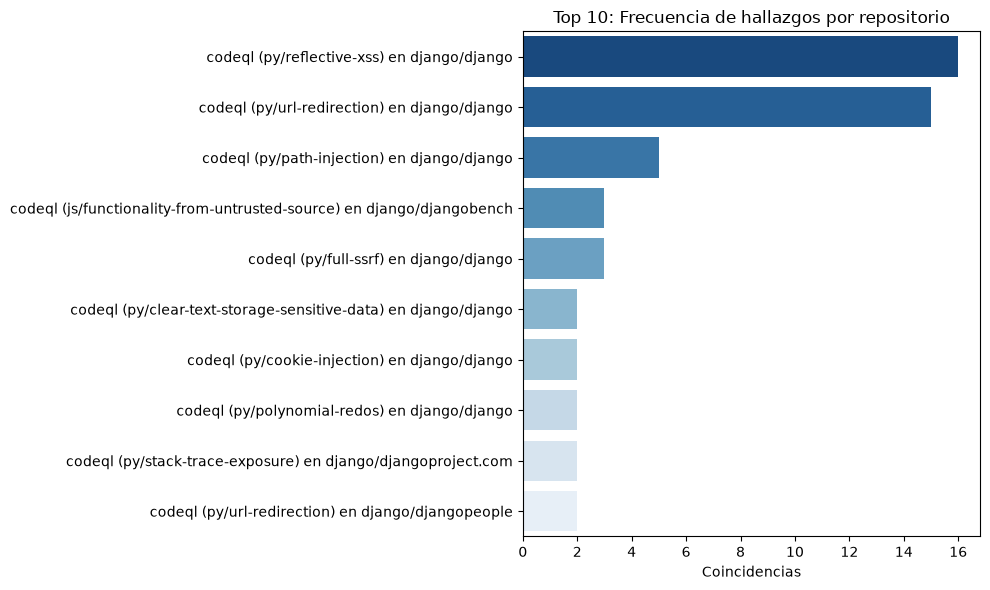

In [6]:
frecuencias = (
    findings.groupby(['tool', 'vulnerability_id', 'repository'])
    .size()
    .rename('coincidencias')
    .reset_index()
    .sort_values(['coincidencias', 'tool', 'vulnerability_id', 'repository'], ascending=[False, True, True, True])
)

import matplotlib.pyplot as plt
import seaborn as sns

# Tomamos el top 10 de frecuencias
top_frecuencias = frecuencias.head(10).copy()

# Creamos una etiqueta combinada para que se entienda bien en el gráfico
top_frecuencias['etiqueta'] = (
    top_frecuencias['tool'] + ' (' + top_frecuencias['vulnerability_id'] + ') en ' + top_frecuencias['repository']
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_frecuencias,
    x='coincidencias',
    y='etiqueta',
    palette='Blues_r'
)
plt.title('Top 10: Frecuencia de hallazgos por repositorio')
plt.xlabel('Coincidencias')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Coincidencias globales y repositorios afectados
Agrupamos los hallazgos a nivel general para identificar cuáles se repiten en más de un proyecto. Los resultados se ordenan de mayor a menor impacto (más repositorios afectados y coincidencias totales primero).

C:\Users\jamar\AppData\Local\Temp\ipykernel_19900\3086587023.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


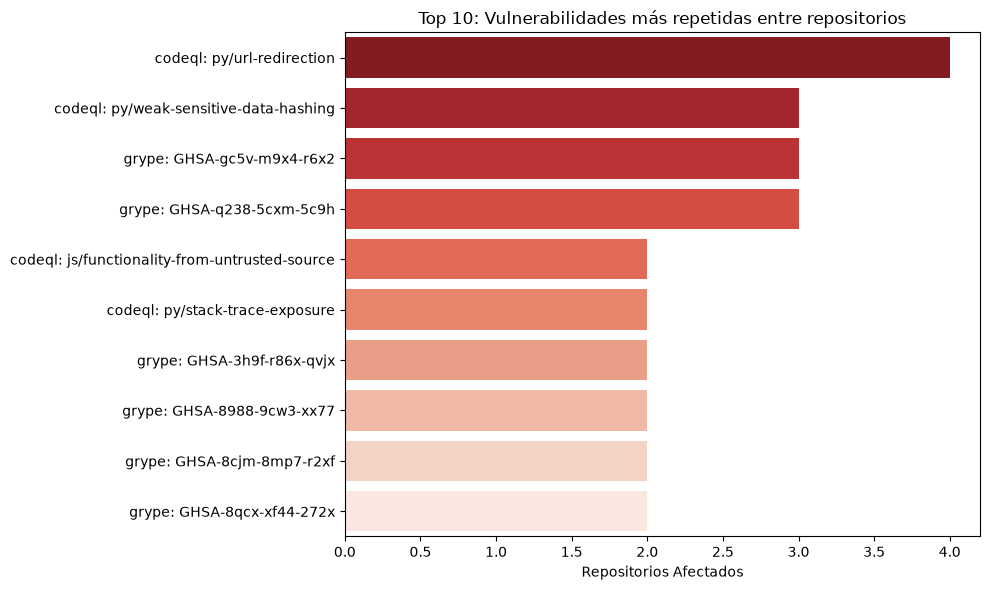

In [7]:
repetidos = (
    frecuencias.groupby(['tool', 'vulnerability_id'])
    .agg(
        repositorios_afectados=('repository', 'nunique'),
        coincidencias_totales=('coincidencias', 'sum'),
    )
    .reset_index()
    .sort_values(
        ['repositorios_afectados', 'coincidencias_totales', 'tool', 'vulnerability_id'],
        ascending=[False, False, True, True],
    )
    .reset_index(drop=True)
)

# Tomamos el top 10 de la tabla de repetidos
top_repetidos = repetidos.head(10).copy()

# Creamos una etiqueta limpia con la herramienta y el ID de vulnerabilidad
top_repetidos['etiqueta'] = top_repetidos['tool'] + ': ' + top_repetidos['vulnerability_id']

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_repetidos,
    x='repositorios_afectados',
    y='etiqueta',
    palette='Reds_r'
)
plt.title('Top 10: Vulnerabilidades más repetidas entre repositorios')
plt.xlabel('Repositorios Afectados')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Pregunta 1. ¿Los hallazgos se concentran en pocos repositorios?

### Método

Contar los registros por repositorio y herramienta y calcular su proporción dentro de cada herramienta.
Incluir todos los repositorios del dataset, conservando el estado del análisis. Un conteo cero no demuestra ausencia de problemas si el análisis falló.

### Resultados


In [8]:
conteos_por_repositorio = (
    findings.groupby(['repository', 'tool'])
    .size()
    .unstack('tool', fill_value=0)
    .reindex(
        index=repositories['repository'],
        columns=['codeql', 'grype'],
        fill_value=0,
    )
    .fillna(0)
    .astype(int)
)

concentracion = (
    conteos_por_repositorio
    .reset_index()
    .melt(
        id_vars='repository',
        var_name='tool',
        value_name='coincidencias',
    )
)
totales_por_herramienta = concentracion.groupby('tool')['coincidencias'].transform('sum')
concentracion['proporcion'] = (
    concentracion['coincidencias'] / totales_por_herramienta.replace(0, float('nan'))
)
concentracion = concentracion.sort_values(
    ['tool', 'coincidencias', 'repository'],
    ascending=[True, False, True],
)

estados_por_herramienta = repositories.melt(
    id_vars='repository',
    value_vars=['codeql_status', 'grype_status'],
    var_name='tool',
    value_name='status',
)
estados_por_herramienta['tool'] = (
    estados_por_herramienta['tool'].str.removesuffix('_status')
)
concentracion = concentracion.merge(
    estados_por_herramienta,
    on=['repository', 'tool'],
    validate='one_to_one',
)

### Comparación visual

Cada panel ordena los repositorios con registros por su participación en el total de la herramienta. Las etiquetas muestran porcentaje y cantidad. Los repositorios sin registros se omiten del gráfico; su estado permanece en la cobertura. El sombreado identifica resultados de análisis incompletos.


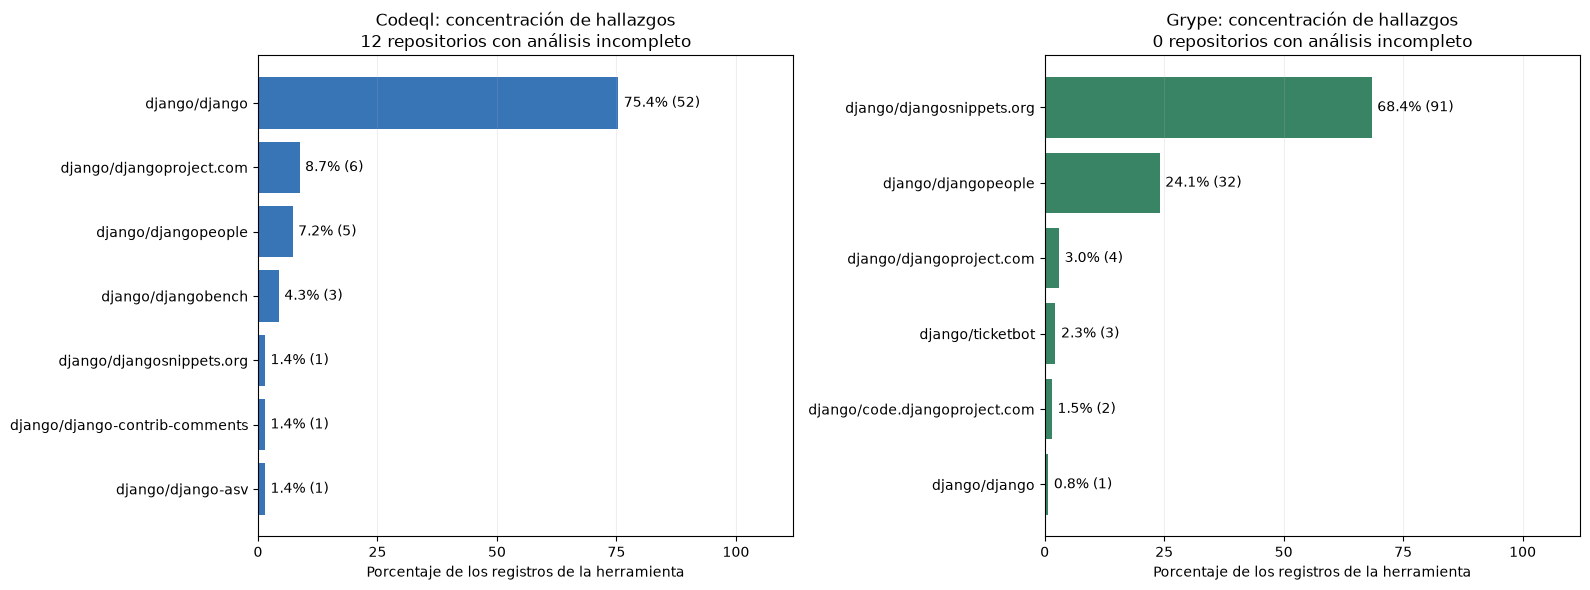

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for axis, tool, color in zip(axes, ['codeql', 'grype'], ['#3875b7', '#398465']):
    data = concentracion.loc[
        concentracion['tool'].eq(tool) & concentracion['coincidencias'].gt(0)
    ].sort_values(['coincidencias', 'repository'])
    if data.empty:
        axis.text(0.5, 0.5, 'Sin registros observados', ha='center', va='center', transform=axis.transAxes)
    else:
        bars = axis.barh(data['repository'], data['proporcion'] * 100, color=color)
        for bar, row in zip(bars, data.itertuples()):
            if row.status != 'analyzed':
                bar.set_hatch('//')
        axis.bar_label(bars, labels=[
            f'{row.proporcion:.1%} ({row.coincidencias})'
            for row in data.itertuples()
        ], padding=4)
    incomplete = concentracion.loc[concentracion['tool'].eq(tool), 'status'].ne('analyzed').sum()
    axis.set_title(f'{tool.capitalize()}: concentración de hallazgos\n{incomplete} repositorios con análisis incompleto')
    axis.set_xlabel('Porcentaje de los registros de la herramienta')
    axis.set_xlim(0, 112)
    axis.set_xticks([0, 25, 50, 75, 100])
    axis.grid(axis='x', alpha=0.2)
fig.tight_layout()
plt.show()


### Interpretación


Los datos confirman de forma categórica que **los hallazgos no se distribuyen de manera uniforme** en la organización, sino que se concentran fuertemente en focos muy específicos según la naturaleza del análisis:

* En el **código fuente propietario (CodeQL)**, el riesgo está hiperconcentrado en el núcleo del framework (`django/django`).
* En la **cadena de suministro (Grype)**, el problema se desplaza masivamente hacia los proyectos auxiliares de la comunidad y servicios complementarios (`django/djangosnippets.org` y `djangopeople`).

### Limitaciones

Los conteos no están ajustados por tamaño del código ni número de dependencias. Se cuentan coincidencias, no vulnerabilidades únicas. La participación de los tres repositorios principales describe concentración observada, sin aplicar un umbral arbitrario para calificarla. Los fallos y la cobertura parcial condicionan la comparación.


## Pregunta 2. ¿Qué reglas de CodeQL son más frecuentes y cuáles se repiten entre proyectos?

### Método

Filtrar CodeQL y agrupar por identificador de regla. Una regla compartida aparece en al menos dos repositorios distintos. Distinguir el número de repositorios afectados del total de coincidencias: muchos casos en un solo proyecto no significan repetición entre proyectos.

### Resultados


In [10]:
reglas_compartidas = repetidos.loc[
    (repetidos['tool'] == 'codeql')
    & (repetidos['repositorios_afectados'] >= 2)
].copy()

repositorios_por_regla = frecuencias.loc[
    (frecuencias['tool'] == 'codeql')
    & frecuencias['vulnerability_id'].isin(reglas_compartidas['vulnerability_id'])
].copy()





### Frecuencia global y por repositorio

Se incluyen todas las reglas observadas, también las que aparecen en un único repositorio. El ranking global cuenta coincidencias; el ranking por repositorio presenta hasta cinco reglas, con desempate por identificador. Los mensajes de ejemplo proceden de la evidencia y ayudan a interpretar el tipo de alerta; no son una confirmación de vulnerabilidad.


In [11]:
codeql_todos = findings.loc[findings['tool'] == 'codeql']
reglas_globales = (
    codeql_todos.groupby('vulnerability_id')
    .agg(coincidencias=('repository', 'size'), repositorios=('repository', 'nunique'),
         ejemplo_mensaje=('description', 'first'))
    .reset_index()
    .sort_values(['coincidencias', 'vulnerability_id'], ascending=[False, True])
)
reglas_globales['proporcion'] = reglas_globales['coincidencias'] / (len(codeql_todos) or float('nan'))
reglas_por_repositorio = frecuencias.loc[frecuencias['tool'] == 'codeql'].copy()
reglas_por_repositorio['proporcion_en_repositorio'] = (
    reglas_por_repositorio['coincidencias']
    / reglas_por_repositorio.groupby('repository')['coincidencias'].transform('sum')
)
reglas_por_repositorio = reglas_por_repositorio.sort_values(
    ['repository', 'coincidencias', 'vulnerability_id'], ascending=[True, False, True],
)
top_reglas_por_repositorio = reglas_por_repositorio.groupby('repository', sort=False).head(5)




### Frecuencia y extensión de las reglas

Los paneles comparan las diez reglas con más registros: a la izquierda su frecuencia y a la derecha cuántos repositorios distintos las presentan. Comparten el orden de las reglas para distinguir una alerta repetida muchas veces en un proyecto de otra extendida entre proyectos.

El mapa de calor muestra qué proporción de los hallazgos de cada repositorio corresponde a esas reglas. Solo incluye repositorios con CodeQL `analyzed` y al menos un hallazgo; las celdas indican porcentajes, con una escala común de 0 a 100. Como se muestran hasta diez reglas, una fila puede sumar menos del 100 %. Los rankings completos y mensajes permanecen en la exportación para el Visualizer.


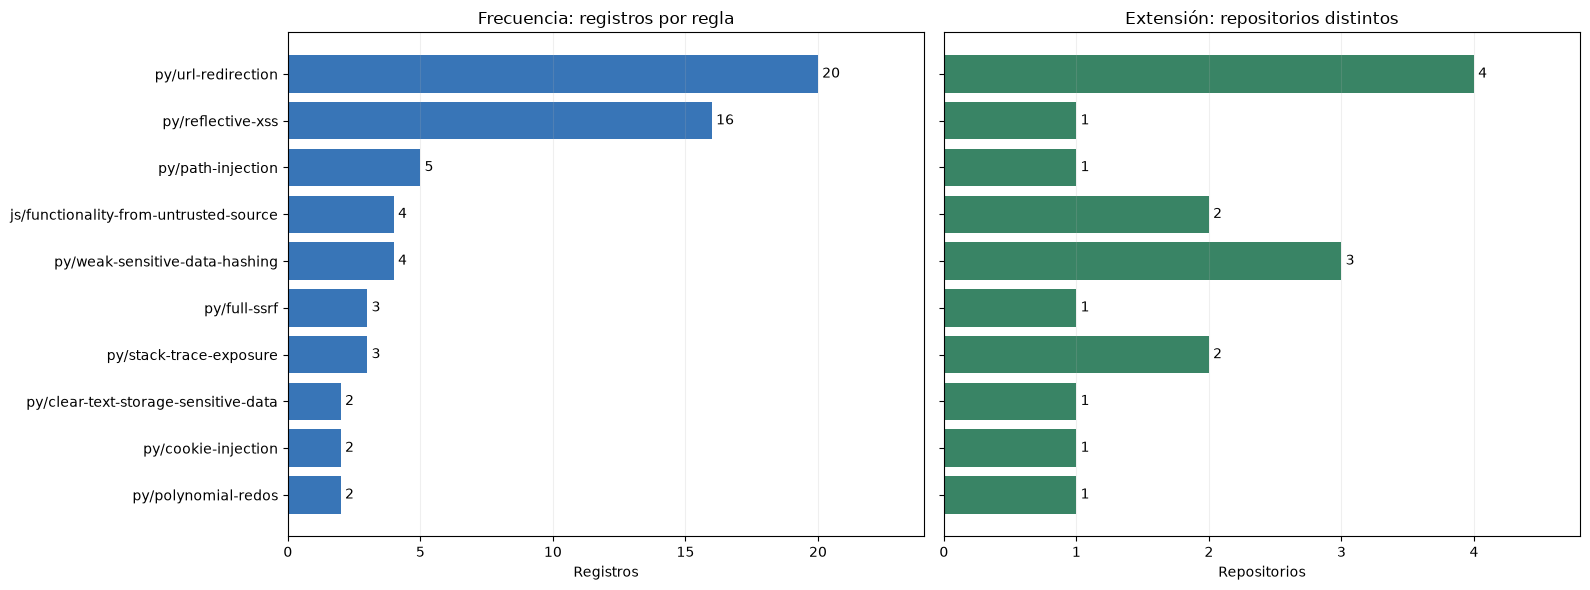

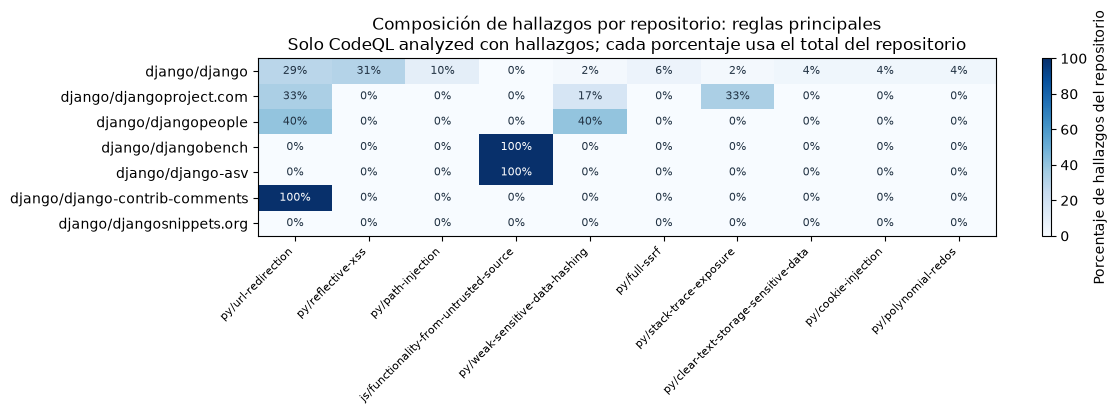

In [12]:
top_reglas_grafico = reglas_globales.head(10).iloc[::-1]
if top_reglas_grafico.empty:
    print('No hay reglas de CodeQL observadas para comparar.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    for axis, column, title, color in [
        (axes[0], 'coincidencias', 'Frecuencia: registros por regla', '#3875b7'),
        (axes[1], 'repositorios', 'Extensión: repositorios distintos', '#398465'),
    ]:
        bars = axis.barh(top_reglas_grafico['vulnerability_id'], top_reglas_grafico[column], color=color)
        axis.bar_label(bars, padding=3, fmt='%.0f')
        axis.set_xlim(0, max(1, top_reglas_grafico[column].max()) * 1.2)
        axis.set_title(title)
        axis.set_xlabel('Registros' if column == 'coincidencias' else 'Repositorios')
        axis.grid(axis='x', alpha=0.2)
    fig.tight_layout()
    plt.show()

repositorios_reglas_completos = repositories.loc[
    repositories['codeql_status'].eq('analyzed'), 'repository'
]
comparacion_reglas = reglas_por_repositorio.loc[
    reglas_por_repositorio['repository'].isin(repositorios_reglas_completos)
].copy()
orden_repositorios_reglas = (
    comparacion_reglas.groupby('repository')['coincidencias'].sum()
    .sort_values(ascending=False).index
)
reglas_mapa = reglas_globales.head(10)['vulnerability_id'].tolist()
mapa_reglas = (
    comparacion_reglas.pivot(
        index='repository', columns='vulnerability_id', values='proporcion_en_repositorio',
    )
    .reindex(index=orden_repositorios_reglas, columns=reglas_mapa)
    .fillna(0) * 100
)
if not mapa_reglas.empty:
    fig, axis = plt.subplots(figsize=(max(12, len(reglas_mapa) * 1.1), max(4, len(mapa_reglas) * 0.6)))
    chart = axis.imshow(mapa_reglas.to_numpy(), cmap='Blues', vmin=0, vmax=100, aspect='auto')
    axis.set_xticks(range(len(mapa_reglas.columns)), labels=mapa_reglas.columns, rotation=45, ha='right', fontsize=8)
    axis.set_yticks(range(len(mapa_reglas.index)), labels=mapa_reglas.index)
    for row_index, values in enumerate(mapa_reglas.to_numpy()):
        for column_index, value in enumerate(values):
            axis.text(column_index, row_index, f'{value:.0f}%', ha='center', va='center',
                      color='white' if value >= 55 else '#223344', fontsize=8)
    axis.set_title('Composición de hallazgos por repositorio: reglas principales\nSolo CodeQL analyzed con hallazgos; cada porcentaje usa el total del repositorio')
    fig.colorbar(chart, ax=axis, label='Porcentaje de hallazgos del repositorio')
    fig.tight_layout()
    plt.show()
else:
    print('No hay repositorios con análisis completo y hallazgos para el mapa de calor.')


### Interpretación


Del análisis detallado de las reglas de CodeQL se desprenden los siguientes hallazgos clave:

* **Regla más frecuente:** La alerta **`py/url-redirection`** encabeza el volumen total con **20 registros (29.0%)** en toda la organización.
* **Regla más extendida:** La misma regla, **`py/url-redirection`**, es la que presenta mayor transversalidad, estando presente en **4 repositorios distintos**.
* **Perfil de repositorio:** Mientras que en proyectos principales como `django/django` las alertas se diversifican entre múltiples reglas (destacando `py/reflective-xss` y `py/url-redirection`), existen proyectos más pequeños y específicos —como `django/djangobench` y `django/django-asv`— donde el 100% de sus pocos hallazgos se concentra en una sola regla (`js/functionality-from-untrusted-source`).

### Limitaciones

Compartir una regla significa compartir un tipo de alerta, no la misma vulnerabilidad concreta. La comparación depende de los lenguajes y repositorios analizados correctamente; no prueba que el problema sea explotable. Los identificadores y mensajes describen lo detectado por la herramienta, sin añadir explicaciones causales no verificadas. El ranking muestra frecuencia, no severidad ni riesgo.


## Pregunta 3. ¿Cómo se distribuyen las severidades y los puntajes, y dónde se concentran los altos?

### Introducción

Esta pregunta estudia la distribución de los hallazgos según los puntajes originales disponibles. Queremos distinguir los repositorios que acumulan muchos hallazgos con puntajes altos de aquellos donde estos representan una proporción importante de los hallazgos puntuados.

Las escalas de CodeQL y Grype se estudian por separado. Una puntuación alta orienta la revisión, pero no confirma la explotabilidad ni determina por sí sola el riesgo del repositorio.

### Método


#### CodeQL: puntaje de la regla

Usaremos el valor original `security-severity` que el Miner extrae de los metadatos de la regla en el SARIF. Es un valor entre **0,0 y 10,0** asociado a la regla o query que generó el hallazgo. GitHub clasifica sus valores como **Low** (0,1–3,9), **Medium** (4,0–6,9), **High** (7,0–8,9) y **Critical** (9,0–10,0). En el dataset se conserva en `scores`, con `system = "security-severity"` y `source = "codeql"`. El Analyzer utiliza `value` directamente: no consulta cada identificador ni convierte `warning`, `error` o `note` en números.

Para las consultas de seguridad incorporadas a las suites Default o Extended, GitHub documenta que el puntaje se asigna a la regla a partir del percentil 75 de los puntajes CVSS de CVE asociados a sus etiquetas CWE. Por ello, representa la severidad del tipo de problema detectado; no es una evaluación CVSS individual de cada ubicación de código ni demuestra su explotabilidad.

Fuente: [GitHub: cálculo de la severidad de seguridad](https://docs.github.com/en/code-security/concepts/code-scanning/code-scanning-alerts#calculation-of-security-severity-levels).

#### Grype: puntajes CVSS publicados

Usaremos los puntajes base que Grype proporciona en `scores`, con `system = "CVSS"`, conservando la fuente, versión, vector e identificador relacionado cuando estén disponibles. No se calcula una puntuación nueva a partir de la etiqueta cualitativa.

#### Decisiones metodológicas

- Se considera puntaje alto un valor mayor o igual a **7,0**.
- Cada hallazgo se cuenta una sola vez. Cuando contiene varios puntajes, se utiliza el máximo como valor representativo para priorización; las fuentes originales permanecen en `scores`.
- Una lista `scores` vacía significa que no hay puntuación disponible: no equivale a cero ni a severidad baja.
- CodeQL y Grype se resumen en filas separadas. Sus valores no se suman ni se promedian entre herramientas.
- La concentración se estudia mediante el número de hallazgos altos, su proporción entre los hallazgos puntuados y la cobertura de puntuación.


In [13]:
HIGH_SCORE_THRESHOLD = 7.0

if scores['value'].isna().any():
    raise ValueError('Hay puntajes sin valor numérico.')
if not scores['value'].between(0, 10).all():
    raise ValueError('Los puntajes deben estar entre 0 y 10.')

# Un valor representativo por hallazgo evita contar varias fuentes CVSS
# como si fueran vulnerabilidades distintas.
representative_scores = (
    scores.sort_values(
        ['finding_index', 'value', 'source'],
        ascending=[True, False, True],
        na_position='last',
    )
    .drop_duplicates('finding_index')
    .rename(columns={
        'value': 'representative_score',
        'system': 'score_system',
        'source': 'score_source',
        'version': 'score_version',
    })
)

scored_findings = (
    findings.reset_index(names='finding_index')
    .merge(
        representative_scores[
            [
                'finding_index',
                'representative_score',
                'score_system',
                'score_source',
                'score_version',
            ]
        ],
        on='finding_index',
        how='inner',
        validate='one_to_one',
    )
)
scored_findings['high_score'] = (
    scored_findings['representative_score'] >= HIGH_SCORE_THRESHOLD
)

### Resultados

La tabla resume la cobertura de puntuación por herramienta. Los gráficos comparan la concentración y las distribuciones; las métricas completas por repositorio se conservan en la exportación para el Visualizer. `proporcion_altos` utiliza como denominador únicamente los hallazgos con puntaje; `proporcion_altos_herramienta` muestra qué fracción de todos los hallazgos altos de esa herramienta pertenece al repositorio.

In [14]:
hallazgos_por_herramienta = findings.groupby('tool').size().rename('hallazgos')
puntuados_por_herramienta = (
    scored_findings.groupby('tool').size().rename('hallazgos_puntuados')
)
altos_por_herramienta = (
    scored_findings.groupby('tool')['high_score'].sum().rename('hallazgos_altos')
)

cobertura_puntajes = (
    pd.concat(
        [hallazgos_por_herramienta, puntuados_por_herramienta, altos_por_herramienta],
        axis=1,
    )
    .fillna(0)
    .astype(int)
)
cobertura_puntajes['cobertura'] = (
    cobertura_puntajes['hallazgos_puntuados'] / cobertura_puntajes['hallazgos']
)
cobertura_puntajes['proporcion_altos'] = (
    cobertura_puntajes['hallazgos_altos']
    / cobertura_puntajes['hallazgos_puntuados'].replace(0, float('nan'))
)

base_repositorios = (
    findings.groupby(['repository', 'tool'])
    .size()
    .rename('hallazgos')
    .reset_index()
)
metricas_puntuadas = (
    scored_findings.groupby(['repository', 'tool'])
    .agg(
        hallazgos_puntuados=('finding_index', 'size'),
        hallazgos_altos=('high_score', 'sum'),
        puntaje_mediano=('representative_score', 'median'),
        puntaje_maximo=('representative_score', 'max'),
    )
    .reset_index()
)

metricas_pregunta_3 = (
    base_repositorios.merge(
        metricas_puntuadas,
        on=['repository', 'tool'],
        how='left',
        validate='one_to_one',
    )
    .fillna({'hallazgos_puntuados': 0, 'hallazgos_altos': 0})
)
metricas_pregunta_3[['hallazgos_puntuados', 'hallazgos_altos']] = (
    metricas_pregunta_3[['hallazgos_puntuados', 'hallazgos_altos']].astype(int)
)
metricas_pregunta_3['cobertura'] = (
    metricas_pregunta_3['hallazgos_puntuados'] / metricas_pregunta_3['hallazgos']
)
metricas_pregunta_3['proporcion_altos'] = (
    metricas_pregunta_3['hallazgos_altos']
    / metricas_pregunta_3['hallazgos_puntuados'].replace(0, float('nan'))
)
totales_altos = metricas_pregunta_3.groupby('tool')['hallazgos_altos'].transform('sum')
metricas_pregunta_3['proporcion_altos_herramienta'] = (
    metricas_pregunta_3['hallazgos_altos'] / totales_altos.replace(0, float('nan'))
)
metricas_pregunta_3 = metricas_pregunta_3.sort_values(
    ['tool', 'hallazgos_altos', 'proporcion_altos', 'repository'],
    ascending=[True, False, False, True],
).reset_index(drop=True)

display(cobertura_puntajes.round(3))


,hallazgos,hallazgos_puntuados,hallazgos_altos,cobertura,proporcion_altos
tool,,,,,
codeql,69,69,39,1.0,0.565
grype,133,133,66,1.0,0.496


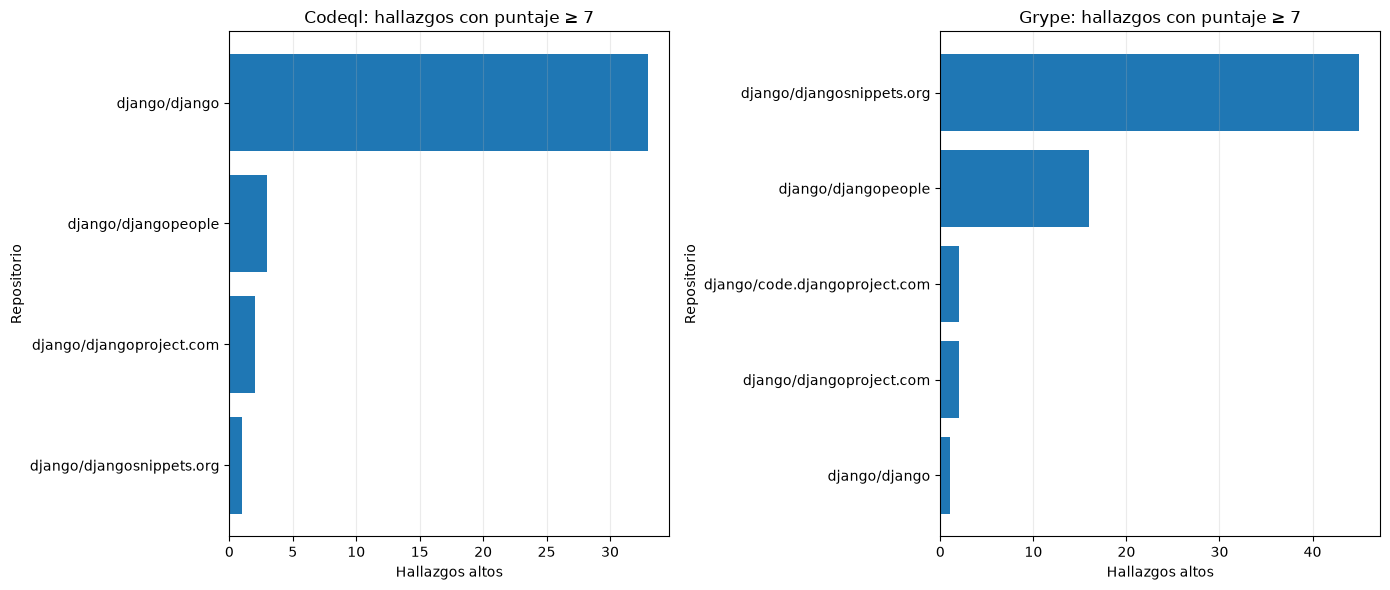

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for axis, tool in zip(axes, ['codeql', 'grype']):
    plot_data = metricas_pregunta_3.loc[
        (metricas_pregunta_3['tool'] == tool)
        & (metricas_pregunta_3['hallazgos_altos'] > 0)
    ].sort_values('hallazgos_altos')
    axis.barh(plot_data['repository'], plot_data['hallazgos_altos'])
    axis.set_title(f'{tool.capitalize()}: hallazgos con puntaje ≥ {HIGH_SCORE_THRESHOLD:g}')
    axis.set_xlabel('Hallazgos altos')
    axis.set_ylabel('Repositorio')
    axis.grid(axis='x', alpha=0.25)

fig.tight_layout()
plt.show()

### Interpretación

El análisis de la distribución de puntajes y severidades arroja conclusiones críticas sobre el perfil de riesgo de la organización:

Cobertura total de puntuación: Tanto CodeQL como Grype presentan una cobertura del 100% (1.0), lo que significa que la totalidad de los hallazgos analizados cuentan con una puntuación asignada, garantizando una base sólida para la evaluación.

Prevalencia de alta severidad (≥7.0): Cerca de la mitad o más de los hallazgos superan el umbral de alto riesgo, registrando un 56.5% en CodeQL (39 hallazgos altos) y un 49.6% en Grype (66 hallazgos altos).

Concentración del riesgo alto: Los puntajes elevados replican la disparidad observada en los volúmenes generales:

En CodeQL, las vulnerabilidades graves de código fuente se concentran fuertemente en el núcleo de django/django.

En Grype, las dependencias con severidad alta se desplazan masivamente hacia los proyectos auxiliares, destacando django/djangosnippets.org y django/djangopeople como los principales focos de vulnerabilidad en la cadena de suministro.

### Limitaciones

Los puntajes de CodeQL pertenecen a las reglas; los CVSS de Grype provienen de vulnerabilidades conocidas. El máximo elegido entre varias fuentes sirve para priorizar y puede ser conservador, pero no sustituye una evaluación de riesgo. No se combinan las herramientas en una única escala ni se infieren valores ausentes. La cobertura del análisis, las versiones CVSS y el tamaño de los proyectos condicionan las conclusiones.

## Pregunta 4. ¿Qué paquetes e identificadores de Grype son más frecuentes y cuáles se comparten?

### Método

Se filtran los hallazgos de Grype y se estudian dos agrupaciones complementarias:

1. **Vulnerabilidades compartidas:** un identificador aparece en al menos dos repositorios distintos.
2. **Paquetes compartidos:** un paquete vulnerable aparece en al menos dos repositorios distintos.

`repositorios_afectados` mide la extensión dentro de la organización. `coincidencias_totales` conserva el número de registros producidos por el Miner. Las versiones y ubicaciones se mantienen para interpretar si los repositorios comparten realmente la misma dependencia afectada.

### Preparativos

In [16]:
grype_findings = findings.loc[findings['tool'] == 'grype'].copy()

if grype_findings.empty:
    raise ValueError('El dataset no contiene hallazgos de Grype.')

vulnerabilidades_grype = (
    grype_findings.groupby('vulnerability_id')
    .agg(
        repositorios_afectados=('repository', 'nunique'),
        coincidencias_totales=('repository', 'size'),
        paquetes_afectados=('package', 'nunique'),
        severidades=('severity', lambda values: sorted(values.dropna().unique())),
    )
    .reset_index()
)

vulnerabilidades_compartidas = (
    vulnerabilidades_grype.loc[
        vulnerabilidades_grype['repositorios_afectados'] >= 2
    ]
    .sort_values(
        ['repositorios_afectados', 'coincidencias_totales', 'vulnerability_id'],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

detalle_vulnerabilidades_compartidas = (
    grype_findings.loc[
        grype_findings['vulnerability_id'].isin(
            vulnerabilidades_compartidas['vulnerability_id']
        ),
        ['vulnerability_id', 'repository', 'package', 'version', 'severity', 'locations'],
    ]
    .sort_values(['vulnerability_id', 'repository', 'package', 'version'])
    .reset_index(drop=True)
)

display(vulnerabilidades_compartidas)

,vulnerability_id,repositorios_afectados,coincidencias_totales,paquetes_afectados,severidades
0,GHSA-gc5v-m9x4-r6x2,3,3,1,[Medium]
1,GHSA-q238-5cxm-5c9h,3,3,1,[Medium]
2,GHSA-3h9f-r86x-qvjx,2,2,1,[Low]
3,GHSA-8988-9cw3-xx77,2,2,1,[High]
4,GHSA-8cjm-8mp7-r2xf,2,2,1,[Low]
5,GHSA-8qcx-xf44-272x,2,2,1,[Medium]
6,GHSA-923m-gv2p-w5qp,2,2,1,[Low]
7,GHSA-9hjg-9r4m-mvj7,2,2,1,[Medium]
8,GHSA-9wx4-h78v-vm56,2,2,1,[Medium]
9,GHSA-crhf-3pfg-w68w,2,2,1,[Medium]


In [17]:
paquetes_grype = (
    grype_findings.dropna(subset=['package'])
    .groupby(['package', 'package_type'], dropna=False)
    .agg(
        repositorios_afectados=('repository', 'nunique'),
        vulnerabilidades_distintas=('vulnerability_id', 'nunique'),
        coincidencias_totales=('repository', 'size'),
        versiones_observadas=('version', lambda values: sorted(values.dropna().unique())),
    )
    .reset_index()
)

paquetes_compartidos = (
    paquetes_grype.loc[paquetes_grype['repositorios_afectados'] >= 2]
    .sort_values(
        [
            'repositorios_afectados',
            'vulnerabilidades_distintas',
            'coincidencias_totales',
            'package',
        ],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

detalle_paquetes_compartidos = (
    grype_findings.merge(
        paquetes_compartidos[['package', 'package_type']],
        on=['package', 'package_type'], how='inner', validate='many_to_one',
    )[['package', 'package_type', 'repository', 'version', 'vulnerability_id', 'severity']]
    .sort_values(['package', 'package_type', 'repository', 'version', 'vulnerability_id'])
    .reset_index(drop=True)
)

ids_frecuentes = vulnerabilidades_grype.nlargest(2, 'coincidencias_totales')['vulnerability_id']
detalle_identificadores_frecuentes = (
    grype_findings.loc[
        grype_findings['vulnerability_id'].isin(ids_frecuentes),
        ['vulnerability_id', 'repository', 'package', 'version', 'severity'],
    ]
    .sort_values(['vulnerability_id', 'repository', 'package', 'version'])
    .reset_index(drop=True)
)

display(paquetes_compartidos)
display(detalle_identificadores_frecuentes)

,package,package_type,repositorios_afectados,vulnerabilidades_distintas,coincidencias_totales,versiones_observadas
0,django,python,3,42,53,"[2.1.10, 5.2.7, 6.1]"
1,requests,python,3,4,8,"[2.22.0, 2.31.0, 2.32.4]"
2,urllib3,python,2,7,9,"[2.5.0, 2.7.0]"
3,gunicorn,python,2,2,4,"[19.9.0, 20.1.0]"
4,psf/black,github-action,2,1,2,"[25.9.0, stable]"


,vulnerability_id,repository,package,version,severity
0,GHSA-gc5v-m9x4-r6x2,django/djangopeople,requests,2.22.0,Medium
1,GHSA-gc5v-m9x4-r6x2,django/djangosnippets.org,requests,2.32.4,Medium
2,GHSA-gc5v-m9x4-r6x2,django/ticketbot,requests,2.31.0,Medium
3,GHSA-q238-5cxm-5c9h,django/djangopeople,django,2.1.10,Medium
4,GHSA-q238-5cxm-5c9h,django/djangoproject.com,django,6.1,Medium
5,GHSA-q238-5cxm-5c9h,django/djangosnippets.org,django,5.2.7,Medium


### Pregunta 4.1: ¿Cuáles son los paquetes e identificadores de Grype más frecuentes en la organización?

**Enfoque**: Volumen total y rankings generales de las dependencias y vulnerabilidades detectadas por la herramienta en toda la muestra.

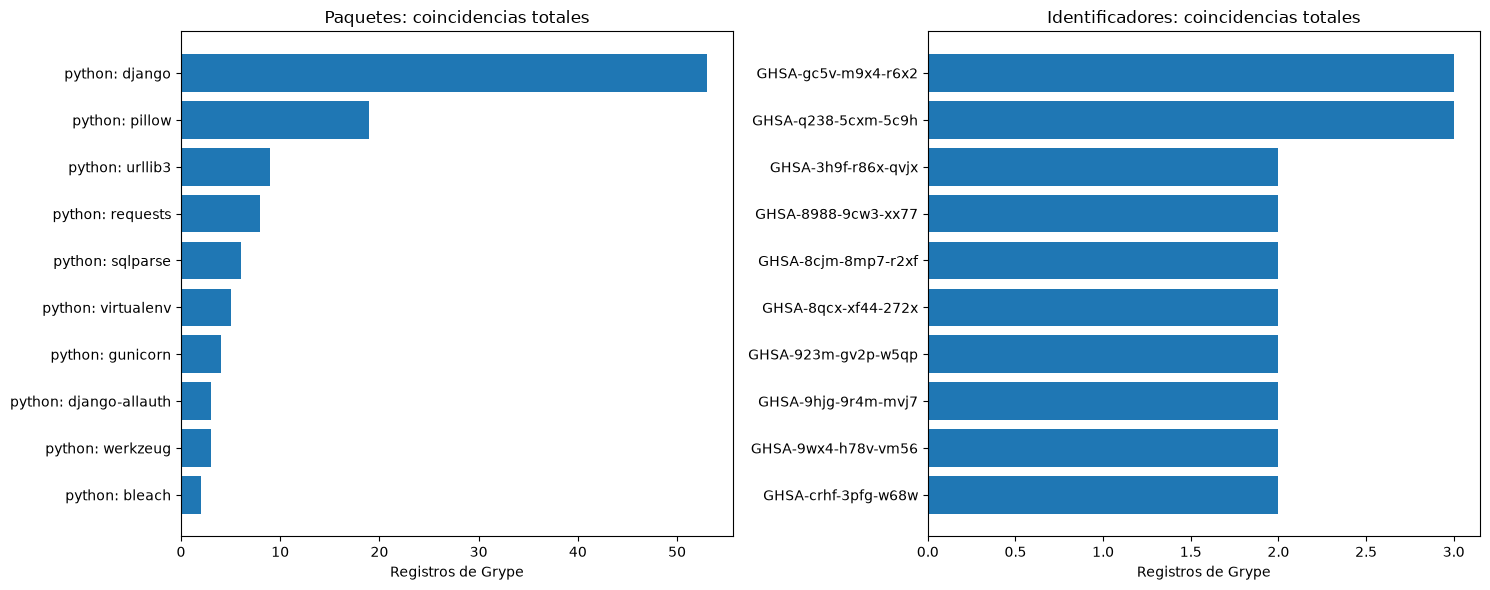

In [18]:
ranking_paquetes_grype = paquetes_grype.sort_values(
    ['coincidencias_totales', 'vulnerabilidades_distintas', 'package_type', 'package'],
    ascending=[False, False, True, True],
).reset_index(drop=True)

ranking_identificadores_grype = vulnerabilidades_grype.sort_values(
    ['coincidencias_totales', 'repositorios_afectados', 'vulnerability_id'],
    ascending=[False, False, True],
).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, frame, label, title in [
    (axes[0], ranking_paquetes_grype, 'package', 'Paquetes: coincidencias totales'),
    (axes[1], ranking_identificadores_grype, 'vulnerability_id', 'Identificadores: coincidencias totales'),
]:
    top = frame.head(10).iloc[::-1]
    labels = (top['package_type'].fillna('Sin tipo') + ': ' + top[label]) if label == 'package' else top[label]
    axis.barh(labels, top['coincidencias_totales'])
    axis.set_title(title)
    axis.set_xlabel('Registros de Grype')

fig.tight_layout()
plt.show()

### Interpretación Pregunta 4.1

En los paquetes, python: django domina abrumadoramente con más de 50 registros de coincidencias, seguido de lejos por python: pillow y otros paquetes del ecosistema Python.

En los identificadores, destacan como los más repetidos `GHSA-gc5v-m9x4-r6x2` y `GHSA-q238-5cxm-5c9h` con 3 registros, mientras que el resto se mantiene en 2.

* **`GHSA-gc5v-m9x4-r6x2` (`requests`):** Aparece en `djangopeople`, `djangosnippets.org` y `ticketbot`. El advisory afecta solo a aplicaciones que llaman directamente a `requests.utils.extract_zipped_paths()` y presupone que un atacante local puede escribir en el directorio temporal; la dependencia por sí sola no demuestra que el sitio sea explotable.
* **`GHSA-q238-5cxm-5c9h` (`django`):** Aparece en `djangopeople`, `djangoproject.com` y `djangosnippets.org`. Describe un DoS al procesar geometrías profundamente anidadas mediante GeoDjango; la coincidencia de Django no demuestra que GeoDjango esté instalado o que la aplicación alcance ese código.

La tabla `detalle_identificadores_frecuentes` desglosa estos identificadores por repositorio, paquete y versión. Son coincidencias de Grype; no acreditan uso en producción, alcanzabilidad ni explotación.

### Pregunta 4.2: ¿Qué paquetes y vulnerabilidades se comparten entre múltiples repositorios?

**Enfoque**: Transversalidad y alcance sistémico (aquello que no es un caso aislado, sino un problema presente en 2 o más repositorios a la vez).

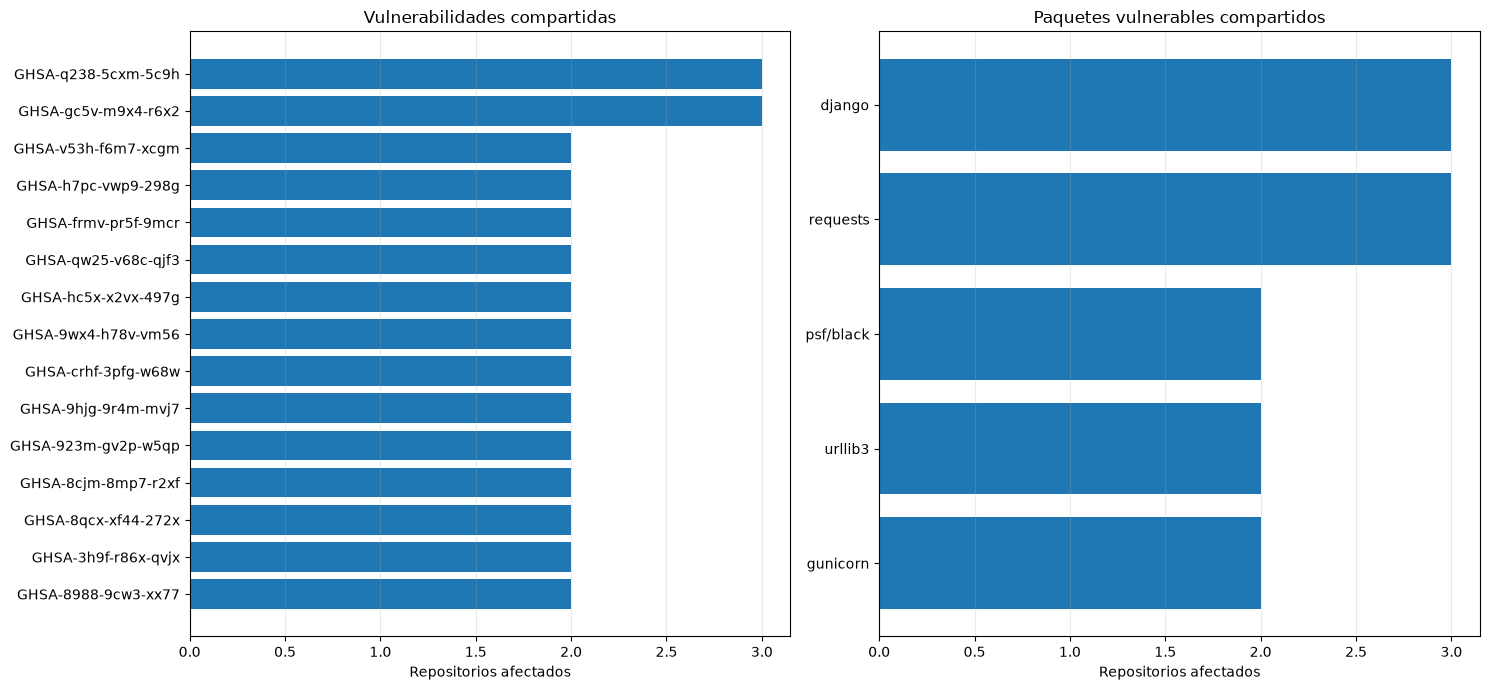

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

top_vulnerabilidades = vulnerabilidades_compartidas.head(15).sort_values(
    'repositorios_afectados'
)
axes[0].barh(
    top_vulnerabilidades['vulnerability_id'],
    top_vulnerabilidades['repositorios_afectados'],
)
axes[0].set_title('Vulnerabilidades compartidas')
axes[0].set_xlabel('Repositorios afectados')
axes[0].grid(axis='x', alpha=0.25)

top_paquetes = paquetes_compartidos.head(15).sort_values('repositorios_afectados')
axes[1].barh(
    top_paquetes['package'],
    top_paquetes['repositorios_afectados'],
)
axes[1].set_title('Paquetes vulnerables compartidos')
axes[1].set_xlabel('Repositorios afectados')
axes[1].grid(axis='x', alpha=0.25)

fig.tight_layout()
plt.show()

### Interpretación Pregunta 4.2

* **Transversalidad de vulnerabilidades:** Los identificadores `GHSA-q238-5cxm-5c9h` y `GHSA-gc5v-m9x4-r6x2` representan el mayor alcance sistémico al encontrarse presentes simultáneamente en **3 repositorios**. El resto de las incidencias transversales se distribuyen de forma uniforme afectando a **2 repositorios**.
* **Paquetes compartidos:** `django` y `requests` lideran la propagación organizacional con presencia en **3 repositorios**, seguidos por dependencias de soporte como `psf/black`, `urllib3` y `gunicorn` en **2 repositorios**, lo que evidencia patrones comunes de reutilización de bases tecnológicas que replican riesgos idénticos en múltiples proyectos.

### Interpretación Pregunta 4

El análisis de Grype evidencia que el riesgo en la organización se concentra de manera sistémica en torno al ecosistema Python, destacando dos frentes principales:

* **Volumen y Frecuencia Global (4.1):** El paquete `python: django` lidera ampliamente el volumen de registros con más de 50 coincidencias, impulsado principalmente por la vulnerabilidad de denegación de servicio `GHSA-q238-5cxm-5c9h` (GeoDjango). A su vez, `GHSA-gc5v-m9x4-r6x2` en `requests` destaca por su alta recurrencia en el manejo de archivos temporales.
* **Transversalidad Organizacional (4.2):** Los paquetes `django` y `requests`, junto con sus respectivas vulnerabilidades críticas, son también los elementos con mayor alcance transversal, replicándose de forma idéntica en **3 repositorios**. Esto demuestra que la reutilización de estos componentes base propaga vulnerabilidades de manera uniforme a lo largo del portafolio de proyectos de la organización.

### Limitaciones

Grype analiza componentes declarados en los SBOM y los contrasta con bases de vulnerabilidades conocidas. Una coincidencia no demuestra que el código vulnerable sea alcanzable durante la ejecución. Un mismo paquete puede aparecer con versiones distintas, y un identificador puede relacionarse con más de una fuente o paquete. Los resultados dependen de la completitud del SBOM y del estado de la base de datos de Grype al momento del análisis.

## Pregunta 5. ¿Existe relación entre los conteos de CodeQL y Grype?

### Introducción

Esta pregunta estudia si los repositorios con más hallazgos de código también tienden a presentar más vulnerabilidades conocidas en sus dependencias. Solo se incluyen repositorios cuyo estado sea `analyzed` tanto en CodeQL como en Grype; así, un análisis fallido no se interpreta como un conteo igual a cero.

### Método: correlación de Spearman

La correlación de Spearman mide si dos variables mantienen una relación **monotónica**: cuando una aumenta, la otra tiende a aumentar o disminuir, aunque la relación no sea lineal. En lugar de comparar directamente los conteos, el método realiza estos pasos:

1. Ordena los repositorios según sus hallazgos de CodeQL y asigna un rango a cada uno.
2. Repite el proceso con los hallazgos de Grype.
3. Cuando varios repositorios empatan, les asigna el rango promedio de las posiciones que ocupan.
4. Calcula la correlación de Pearson entre ambas columnas de rangos.

El coeficiente resultante, **rho de Spearman (`ρ`)**, está entre `-1` y `1`:

- `ρ` cercano a `1`: los repositorios con más hallazgos de CodeQL tienden a tener más hallazgos de Grype.
- `ρ` cercano a `-1`: los repositorios con más hallazgos de una herramienta tienden a tener menos de la otra.
- `ρ` cercano a `0`: no se observa una relación monotónica clara.

Se usa Spearman porque los conteos tienen muchos empates y valores extremos, y no se puede asumir una distribución normal ni una relación lineal. El cálculo se realiza directamente con los rangos para no incorporar una dependencia adicional.

In [20]:
repositorios_cobertura_completa = repositories.loc[
    (repositories['codeql_status'] == 'analyzed')
    & (repositories['grype_status'] == 'analyzed'),
    ['repository', 'codeql_status', 'grype_status'],
]

conteos_relacion = (
    conteos_por_repositorio.reset_index()
    .merge(
        repositorios_cobertura_completa,
        on='repository',
        how='inner',
        validate='one_to_one',
    )
    .rename(columns={'codeql': 'hallazgos_codeql', 'grype': 'hallazgos_grype'})
)

if len(conteos_relacion) < 2:
    raise ValueError('Se necesitan al menos dos repositorios con cobertura completa.')
if (
    conteos_relacion['hallazgos_codeql'].nunique() < 2
    or conteos_relacion['hallazgos_grype'].nunique() < 2
):
    raise ValueError('Los conteos no tienen variación suficiente para calcular Spearman.')

conteos_relacion['rango_codeql'] = conteos_relacion['hallazgos_codeql'].rank(
    method='average'
)
conteos_relacion['rango_grype'] = conteos_relacion['hallazgos_grype'].rank(
    method='average'
)
rho_spearman = conteos_relacion['rango_codeql'].corr(
    conteos_relacion['rango_grype']
)

conteos_relacion = conteos_relacion.sort_values(
    ['hallazgos_codeql', 'hallazgos_grype', 'repository'],
    ascending=[False, False, True],
).reset_index(drop=True)

print(f'Repositorios incluidos: {len(conteos_relacion)}')
print(f'Rho de Spearman: {rho_spearman:.3f}')

Repositorios incluidos: 19
Rho de Spearman: 0.513


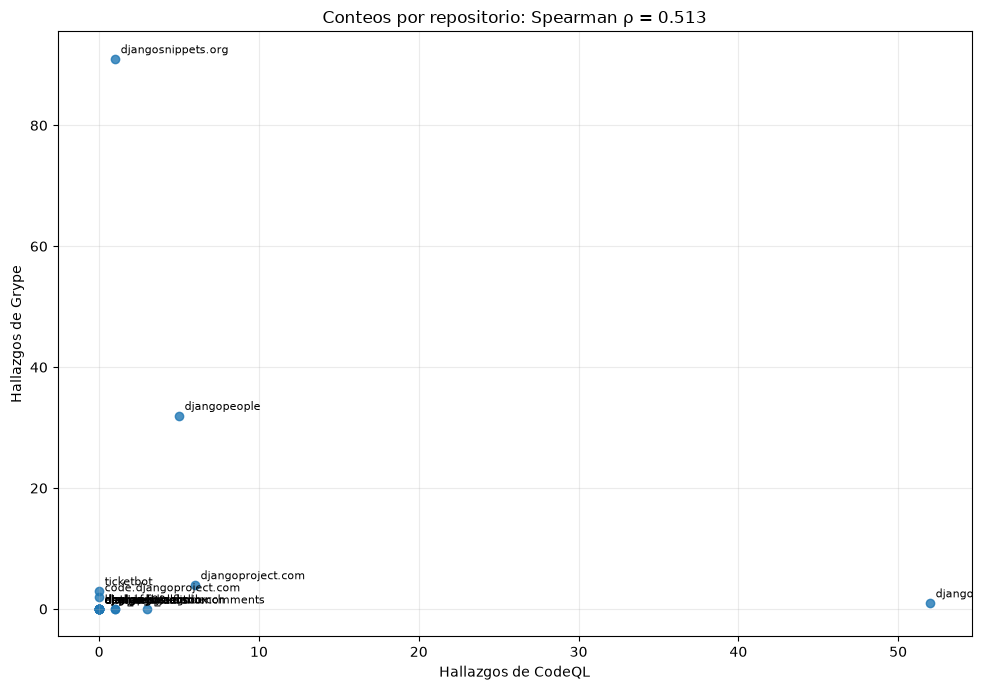

In [21]:
fig, axis = plt.subplots(figsize=(10, 7))
axis.scatter(
    conteos_relacion['hallazgos_codeql'],
    conteos_relacion['hallazgos_grype'],
    alpha=0.8,
)

for row in conteos_relacion.itertuples():
    axis.annotate(
        row.repository.removeprefix(f"{dataset['organization']}/"),
        (row.hallazgos_codeql, row.hallazgos_grype),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )

axis.set_title(f'Conteos por repositorio: Spearman ρ = {rho_spearman:.3f}')
axis.set_xlabel('Hallazgos de CodeQL')
axis.set_ylabel('Hallazgos de Grype')
axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Interpretación

* **Tendencia general y asociación moderada ($\rho = 0.513$):** El coeficiente obtenido indica una tendencia monótona positiva moderada entre ambos analizadores. Esto sugiere que, a nivel general, los repositorios que acumulan una mayor cantidad de vulnerabilidades de código detectadas por CodeQL también tienden a presentar un volumen mayor de vulnerabilidades en sus dependencias según Grype.
* **Presencia de valores atípicos significativos:** 
  * **`djangosnippets.org`** destaca de forma masiva en la parte superior con un volumen crítico de hallazgos en Grype (~90) a pesar de tener un conteo bajo en CodeQL, lo que evidencia que el riesgo principal de este repositorio reside en sus dependencias externas de terceros más que en su código fuente propio.
  * **`djangopeople`** se posiciona de forma separada en la zona intermedia-alta, acumulando un volumen importante en dependencias (~32) frente a un conteo bajo-moderado en CodeQL (~5).
  * **`django`** se comporta de manera inversa y aislada en el extremo derecho, registrando una gran cantidad de hallazgos de código en CodeQL (~52) pero con un conteo mínimo en Grype, reflejando un proyecto fuertemente expuesto a nivel de lógica interna o código base pero con dependencias relativamente controladas.
* **Concentración del portafolio:** La gran mayoría de los repositorios restantes se agrupan densamente en la esquina inferior izquierda con conteos bajos para ambas herramientas, lo que denota que un porcentaje importante del portafolio mantiene una superficie de exposición reducida tanto en código como en dependencias.

### Limitaciones

La correlación describe asociación, no causalidad: los hallazgos de código no producen necesariamente vulnerabilidades en dependencias. Los conteos no están normalizados por líneas de código, cantidad de dependencias ni tamaño del repositorio. La muestra es pequeña y contiene empates y valores extremos; por ello se informan el coeficiente, el gráfico y el número de repositorios incluidos, sin afirmar significancia estadística. CodeQL y Grype además observan dimensiones de seguridad diferentes.

## Pregunta 6. ¿En qué archivos se concentran los hallazgos de CodeQL dentro de cada repositorio?

### Método

Se estudian los hallazgos de CodeQL y sus rutas en `locations`. Cada registro del dataset recibe un `finding_index`; si menciona varias veces el mismo archivo, se cuenta una sola vez en ese archivo. Si menciona archivos distintos, contribuye una vez a cada uno.

Se presentan los tres archivos con más hallazgos por repositorio, el número de reglas distintas y la proporción respecto de todos los hallazgos de CodeQL del repositorio. Los empates se resuelven por ruta alfabética para obtener un máximo de tres archivos reproducible.

La concentración conjunta del top 3 usa la **unión de hallazgos** asociados a esos archivos: un hallazgo presente en dos archivos del top se cuenta una sola vez. Las proporciones individuales por archivo no deben sumarse.

Se informa además la cobertura de ubicación y el estado de CodeQL para todos los repositorios. Los repositorios sin hallazgos tienen proporciones no definidas; un fallo de análisis no se interpreta como ausencia de problemas.


In [22]:
codeql_archivos = (
    findings.loc[findings['tool'] == 'codeql']
    .reset_index(names='finding_index')
    .copy()
)

def rutas_unicas(locations):
    if not isinstance(locations, list):
        return []
    return sorted({
        location.strip().replace('\\', '/')
        for location in locations
        if isinstance(location, str) and location.strip()
    })

codeql_archivos['archivos'] = codeql_archivos['locations'].map(rutas_unicas)
ubicaciones_codeql = (
    codeql_archivos[['finding_index', 'repository', 'vulnerability_id', 'archivos']]
    .explode('archivos')
    .rename(columns={'archivos': 'archivo'})
    .dropna(subset=['archivo'])
    .drop_duplicates(['finding_index', 'archivo'])
)

resumen_archivos = (
    repositories[['repository', 'codeql_status']]
    .merge(
        codeql_archivos.groupby('repository').size().rename('hallazgos_codeql'),
        on='repository', how='left', validate='one_to_one',
    )
    .merge(
        ubicaciones_codeql.groupby('repository').agg(
            hallazgos_con_ubicacion=('finding_index', 'nunique'),
            archivos_con_hallazgos=('archivo', 'nunique'),
        ),
        on='repository', how='left', validate='one_to_one',
    )
)
columnas_conteo = ['hallazgos_codeql', 'hallazgos_con_ubicacion', 'archivos_con_hallazgos']
resumen_archivos[columnas_conteo] = resumen_archivos[columnas_conteo].fillna(0).astype(int)
resumen_archivos['hallazgos_sin_ubicacion'] = (
    resumen_archivos['hallazgos_codeql'] - resumen_archivos['hallazgos_con_ubicacion']
)
resumen_archivos['cobertura_ubicacion'] = (
    resumen_archivos['hallazgos_con_ubicacion']
    / resumen_archivos['hallazgos_codeql'].replace(0, float('nan'))
)

hallazgos_por_archivo = (
    ubicaciones_codeql.groupby(['repository', 'archivo'])
    .agg(
        hallazgos=('finding_index', 'nunique'),
        reglas_distintas=('vulnerability_id', 'nunique'),
    )
    .reset_index()
    .merge(
        resumen_archivos[['repository', 'codeql_status', 'hallazgos_codeql']],
        on='repository', how='left', validate='many_to_one',
    )
)
hallazgos_por_archivo['proporcion_del_repositorio'] = (
    hallazgos_por_archivo['hallazgos'] / hallazgos_por_archivo['hallazgos_codeql']
)
hallazgos_por_archivo = hallazgos_por_archivo.sort_values(
    ['repository', 'hallazgos', 'archivo'], ascending=[True, False, True],
).reset_index(drop=True)
top_archivos = hallazgos_por_archivo.groupby('repository', sort=False).head(3).copy()

hallazgos_top_3 = (
    ubicaciones_codeql.merge(
        top_archivos[['repository', 'archivo']],
        on=['repository', 'archivo'], how='inner', validate='many_to_one',
    )
    .groupby('repository')['finding_index'].nunique()
    .rename('hallazgos_en_top_3')
)
resumen_archivos = resumen_archivos.merge(
    hallazgos_top_3, on='repository', how='left', validate='one_to_one',
)
resumen_archivos['hallazgos_en_top_3'] = resumen_archivos['hallazgos_en_top_3'].fillna(0).astype(int)
resumen_archivos['proporcion_top_3'] = (
    resumen_archivos['hallazgos_en_top_3']
    / resumen_archivos['hallazgos_codeql'].replace(0, float('nan'))
)
resumen_archivos = resumen_archivos.sort_values(
    ['hallazgos_codeql', 'repository'], ascending=[False, True],
).reset_index(drop=True)

print(f"Procesamiento completado. Repositorios analizados: {len(resumen_archivos)}")

Procesamiento completado. Repositorios analizados: 31


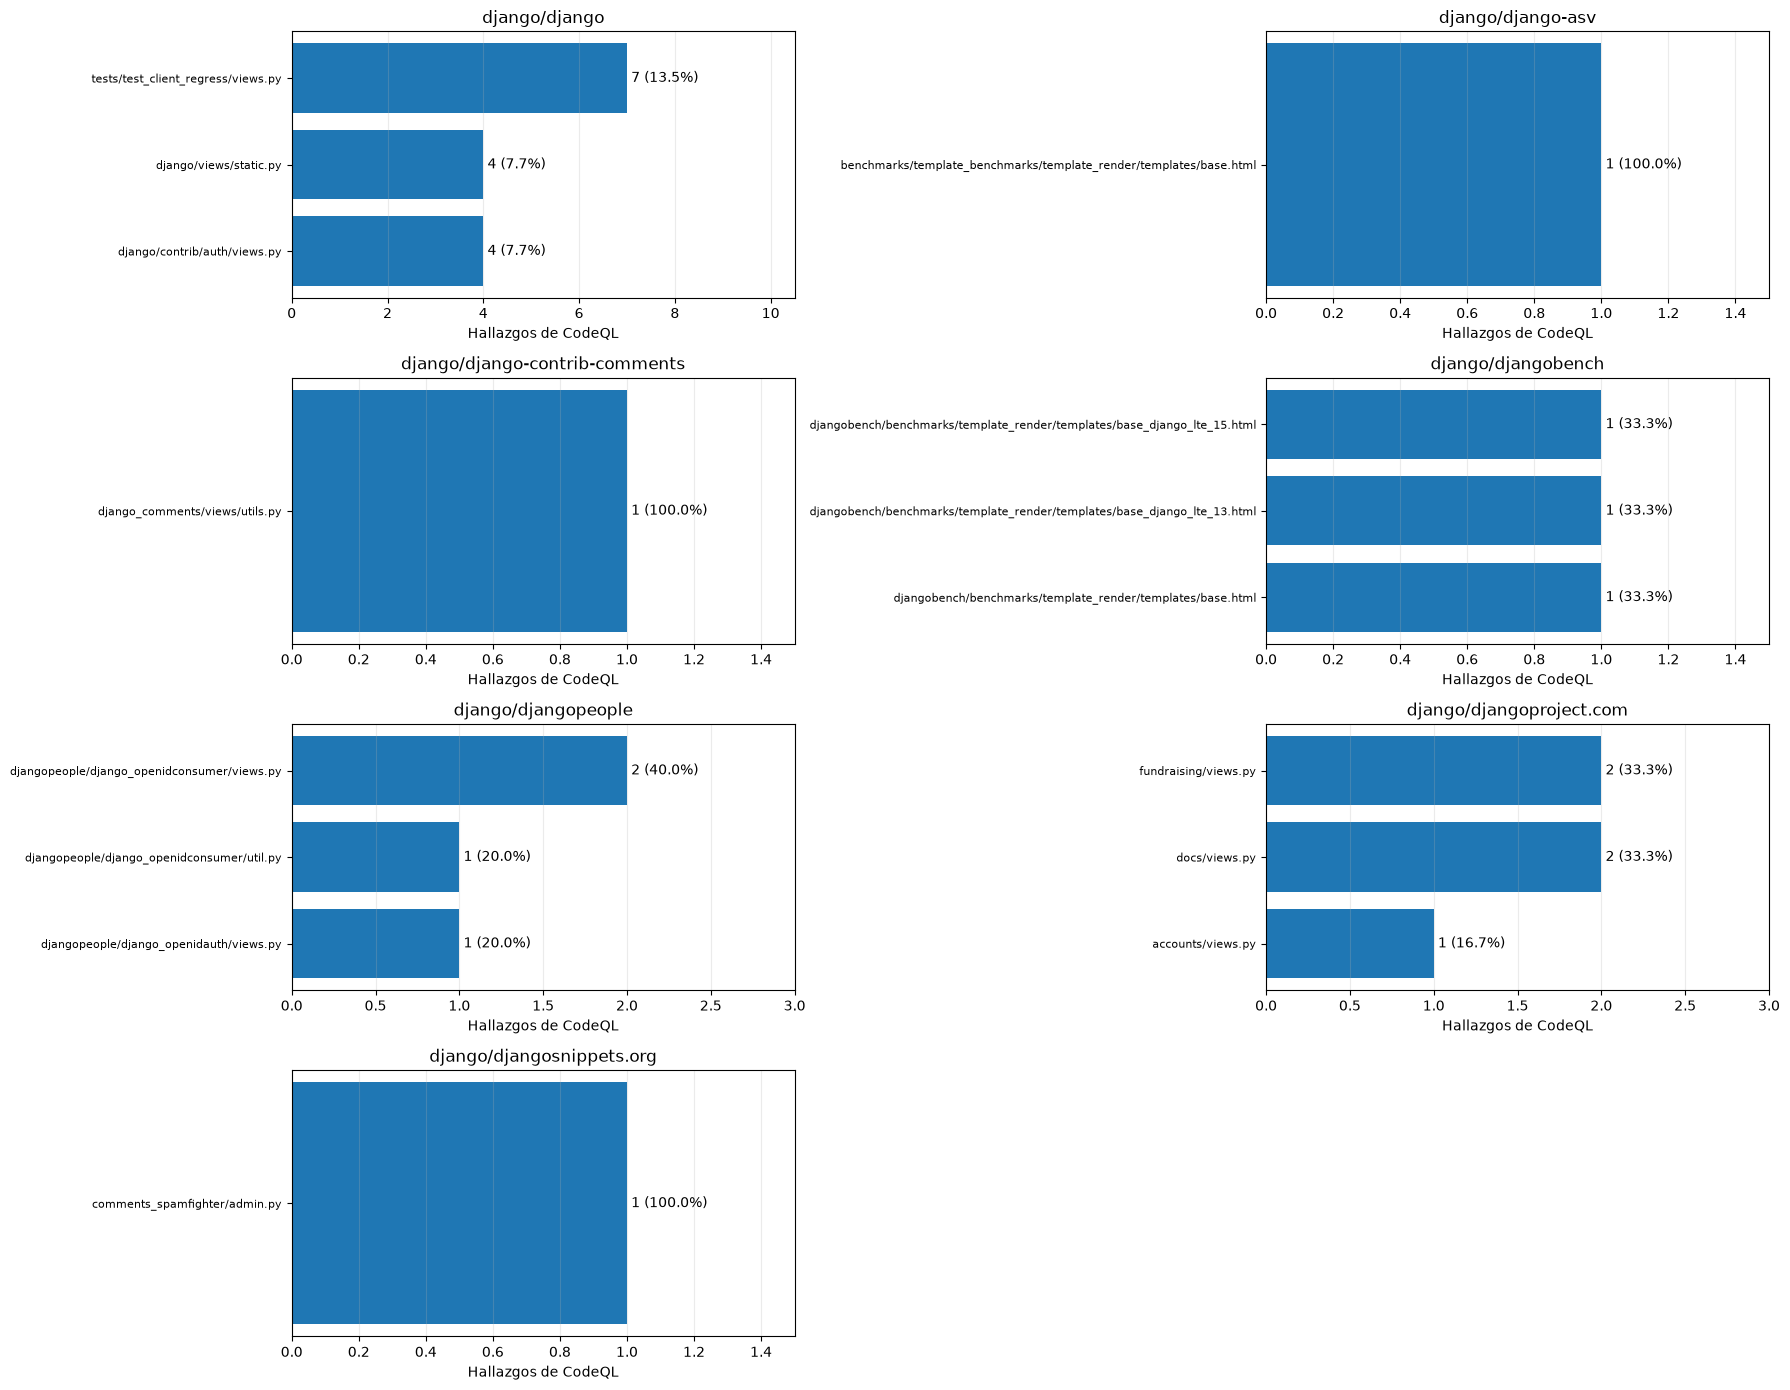

In [23]:
repositorios_con_archivos = top_archivos['repository'].drop_duplicates().tolist()

if not repositorios_con_archivos:
    print('No hay hallazgos de CodeQL con rutas de archivo disponibles.')
else:
    filas = (len(repositorios_con_archivos) + 1) // 2
    fig, axes = plt.subplots(filas, 2, figsize=(18, 3.5 * filas), squeeze=False)
    
    for axis, repository in zip(axes.flat, repositorios_con_archivos):
        datos_archivo = top_archivos.loc[
            top_archivos['repository'] == repository
        ].sort_values(['hallazgos', 'archivo'])
        
        barras = axis.barh(datos_archivo['archivo'], datos_archivo['hallazgos'])
        
        axis.bar_label(barras, labels=[
            f'{row.hallazgos} ({row.proporcion_del_repositorio:.1%})'
            for row in datos_archivo.itertuples()
        ], padding=3)
        
        axis.set_xlim(0, datos_archivo['hallazgos'].max() * 1.5)
        axis.set_title(repository)
        axis.set_xlabel('Hallazgos de CodeQL')
        axis.tick_params(axis='y', labelsize=8)
        axis.grid(axis='x', alpha=0.25)
        
    for axis in list(axes.flat)[len(repositorios_con_archivos):]:
        axis.set_visible(False)
        
    fig.tight_layout()
    plt.show()

### Interpretación


* **Concentración en el repositorio principal (`django/django`):** En el proyecto de mayor envergadura, los hallazgos se distribuyen de manera más dispersa entre archivos clave del framework, destacando `tests/test_client_regress/views.py` con el mayor volumen (7 hallazgos, representando el 13.5% del total del repositorio), seguido por módulos de vistas estáticas y autenticación.
* **Proyectos de bajo volumen y alta concentración:** En repositorios más acotados (como `django/django-asv`, `django/django-contrib-comments` o `django/djangosnippets.org`), el 100% de los hallazgos se concentra en un único archivo (`base.html`, `utils.py` o `admin.py` respectivamente), lo que indica que las incidencias de código están altamente localizadas en componentes específicos o scripts puntuales de administración y pruebas.
* **Distribución equilibrada en utilidades y documentación:** Repositorios como `django/djangobench` y `django/djangoproject.com` muestran una distribución más equitativa entre sus tres principales archivos afectados, repartiendo el peso de los hallazgos de manera uniforme entre documentación, scripts de rendimiento y vistas de cuentas o recaudación.

### Limitaciones

Se cuentan alertas de CodeQL, no vulnerabilidades confirmadas. Las rutas proceden de las ubicaciones conservadas por el Miner; no representan necesariamente todo el recorrido del flujo de datos de una alerta.

La concentración no está normalizada por líneas de código ni tamaño del archivo. Un porcentaje alto puede corresponder a muy pocos hallazgos o a un repositorio pequeño. Se incluyen archivos de pruebas y ejemplos: su contexto debe revisarse antes de priorizar. Los análisis fallidos o parciales y las ubicaciones ausentes limitan las conclusiones.


## Pregunta 7. ¿Qué ecosistemas predominan en el inventario de componentes y cómo varían entre repositorios?

### Método

Se utiliza el inventario CycloneDX completo de la ejecución seleccionada en `SBOM_REPORT_PATH`, incluidos componentes sin coincidencias de Grype. El reporte `sbom-results.json` identifica cada repositorio, su estado y el archivo que corresponde cargar. Las rutas originales se resuelven por nombre de archivo dentro de la copia local de esa ejecución.

La unidad de conteo es cada registro de `components`, coherente con `component_count` del Miner. Se cuentan apariciones en los inventarios: un paquete repetido en distintos repositorios contribuye a cada uno. No se interpreta este total como paquetes únicos ni como dependencias directas.

Para clasificar el ecosistema se utiliza `syft:package:type`: `python` se presenta como **PyPI**, `npm` como **npm** y los tipos `github-action` y `github-action-workflow` como **GitHub Actions**. Si falta ese dato, se usa el tipo de PURL (`pypi`, `npm`, etc.); un PURL `github` sin el tipo de Syft se mantiene como **GitHub (PURL)**, sin asumir que sea una acción. Los demás tipos se conservan identificados por su fuente y los componentes sin clasificación se agrupan como **Sin clasificar**. El campo CycloneDX `type` (por ejemplo, `library`) no se usa como ecosistema.

Se calculan cantidades, proporciones y repositorios con presencia de cada ecosistema. La distribución por repositorio usa como denominador sus componentes inventariados. Un SBOM válido sin componentes se muestra como vacío, con proporciones no definidas; fallos, archivos ausentes y documentos inválidos se muestran aparte y no cuentan como inventarios vacíos.


In [24]:
def ecosistema_componente(component):
    properties = component.get('properties', [])
    syft_type = next((
        item.get('value') for item in properties
        if isinstance(item, dict) and item.get('name') == 'syft:package:type'
        and isinstance(item.get('value'), str) and item['value'].strip()
    ), None) if isinstance(properties, list) else None
    if syft_type:
        syft_type = syft_type.strip().lower()
        label = {'python': 'PyPI', 'npm': 'npm', 'github-action': 'GitHub Actions', 'github-action-workflow': 'GitHub Actions'}.get(
            syft_type, f'Syft: {syft_type}',
        )
        return label, 'syft:package:type'
    purl = component.get('purl')
    if isinstance(purl, str) and purl.startswith('pkg:') and '/' in purl[4:]:
        purl_type = purl[4:].split('/', 1)[0].lower()
        if purl_type:
            label = {'pypi': 'PyPI', 'npm': 'npm', 'github': 'GitHub (PURL)'}.get(
                purl_type, f'PURL: {purl_type}',
            )
            return label, 'purl'
    return 'Sin clasificar', 'sin_dato'


def cargar_inventario_sbom(report_path, organization, repository_names):
    with report_path.open(encoding='utf-8') as report_file:
        report = json.load(report_file)
    if not isinstance(report, dict) or report.get('organization') != organization:
        raise ValueError('El reporte SBOM no corresponde a la organización seleccionada.')
    records = report.get('repositories')
    if not isinstance(records, list):
        raise ValueError('El reporte SBOM debe contener una lista de repositorios.')

    coverage_rows, component_rows, seen = [], [], set()
    for record in records:
        if not isinstance(record, dict):
            raise ValueError('Registro inválido en el reporte SBOM.')
        repository = record.get('full_name')
        if repository not in repository_names or repository in seen:
            raise ValueError(f'Repositorio desconocido o repetido en SBOM: {repository}')
        seen.add(repository)
        row = {
            'repository': repository,
            'sbom_status': record.get('status'),
            'componentes_reportados': record.get('component_count'),
            'componentes_cargados': None,
            'sbom_vacio': None,
            'error': record.get('error'),
        }
        if row['sbom_status'] not in {'generated', 'failed'}:
            raise ValueError(f'Estado SBOM no reconocido: {row["sbom_status"]}')
        if row['sbom_status'] == 'generated':
            try:
                stored_path = record.get('sbom_path')
                if not isinstance(stored_path, str) or not stored_path.strip():
                    raise ValueError('El reporte no contiene una ruta de SBOM.')
                filename = stored_path.replace('\\', '/').rsplit('/', 1)[-1]
                local_path = report_path.parent / filename
                with local_path.open(encoding='utf-8') as sbom_file:
                    document = json.load(sbom_file)
                if not isinstance(document, dict) or document.get('bomFormat') != 'CycloneDX':
                    raise ValueError('El archivo no es un documento CycloneDX.')
                components = document.get('components', [])
                if not isinstance(components, list) or any(not isinstance(c, dict) for c in components):
                    raise ValueError('La lista de componentes es inválida.')
                if len(components) != record.get('component_count'):
                    raise ValueError('El número de componentes difiere del reporte del Miner.')
            except FileNotFoundError as error:
                row.update(sbom_status='missing', error=str(error))
            except (OSError, ValueError) as error:
                row.update(sbom_status='invalid', error=str(error))
            else:
                row.update(componentes_cargados=len(components), sbom_vacio=not components)
                for index, component in enumerate(components):
                    ecosystem, classification_source = ecosistema_componente(component)
                    component_rows.append({
                        'repository': repository,
                        'component_index': index,
                        'name': component.get('name'),
                        'version': component.get('version'),
                        'purl': component.get('purl'),
                        'ecosistema': ecosystem,
                        'fuente_clasificacion': classification_source,
                    })
        coverage_rows.append(row)
    for repository in sorted(repository_names - seen):
        coverage_rows.append({
            'repository': repository, 'sbom_status': 'not_reported',
            'componentes_reportados': None, 'componentes_cargados': None,
            'sbom_vacio': None, 'error': 'Repositorio ausente del reporte SBOM.',
        })
    coverage_df = pd.DataFrame(coverage_rows, columns=[
        'repository', 'sbom_status', 'componentes_reportados',
        'componentes_cargados', 'sbom_vacio', 'error',
    ]).sort_values('repository').reset_index(drop=True)
    components_df = pd.DataFrame(component_rows, columns=[
        'repository', 'component_index', 'name', 'version', 'purl',
        'ecosistema', 'fuente_clasificacion',
    ])
    return coverage_df, components_df


cobertura_sbom, componentes_sbom = cargar_inventario_sbom(
    SBOM_REPORT_PATH, dataset['organization'], set(repositories['repository']),
)
print(f"Inventario SBOM cargado con éxito. Total de componentes procesados: {len(componentes_sbom)}")

Inventario SBOM cargado con éxito. Total de componentes procesados: 310


In [25]:
repositorios_sbom_validos = cobertura_sbom.loc[
    cobertura_sbom['sbom_status'] == 'generated', 'repository',
]
resumen_ecosistemas = (
    componentes_sbom.groupby('ecosistema')
    .agg(componentes=('component_index', 'size'), repositorios=('repository', 'nunique'))
    .reset_index()
    .sort_values(['componentes', 'ecosistema'], ascending=[False, True])
    .reset_index(drop=True)
)
resumen_ecosistemas['proporcion_componentes'] = (
    resumen_ecosistemas['componentes'] / (len(componentes_sbom) or float('nan'))
)
resumen_ecosistemas['proporcion_repositorios'] = (
    resumen_ecosistemas['repositorios'] / (len(repositorios_sbom_validos) or float('nan'))
)

componentes_por_ecosistema = (
    componentes_sbom.groupby(['repository', 'ecosistema'])
    .size().rename('componentes').reset_index()
)
totales_sbom = componentes_por_ecosistema.groupby('repository')['componentes'].transform('sum')
componentes_por_ecosistema['proporcion'] = componentes_por_ecosistema['componentes'] / totales_sbom

matriz_ecosistemas = (
    componentes_por_ecosistema.pivot(index='repository', columns='ecosistema', values='componentes')
    .reindex(index=repositorios_sbom_validos, columns=resumen_ecosistemas['ecosistema'])
    .fillna(0).astype(int)
)
proporciones_ecosistemas = matriz_ecosistemas.div(
    matriz_ecosistemas.sum(axis=1).replace(0, float('nan')), axis=0,
)

print(f"Resumen de ecosistemas procesado. Ecosistemas detectados: {len(resumen_ecosistemas)}")

Resumen de ecosistemas procesado. Ecosistemas detectados: 3


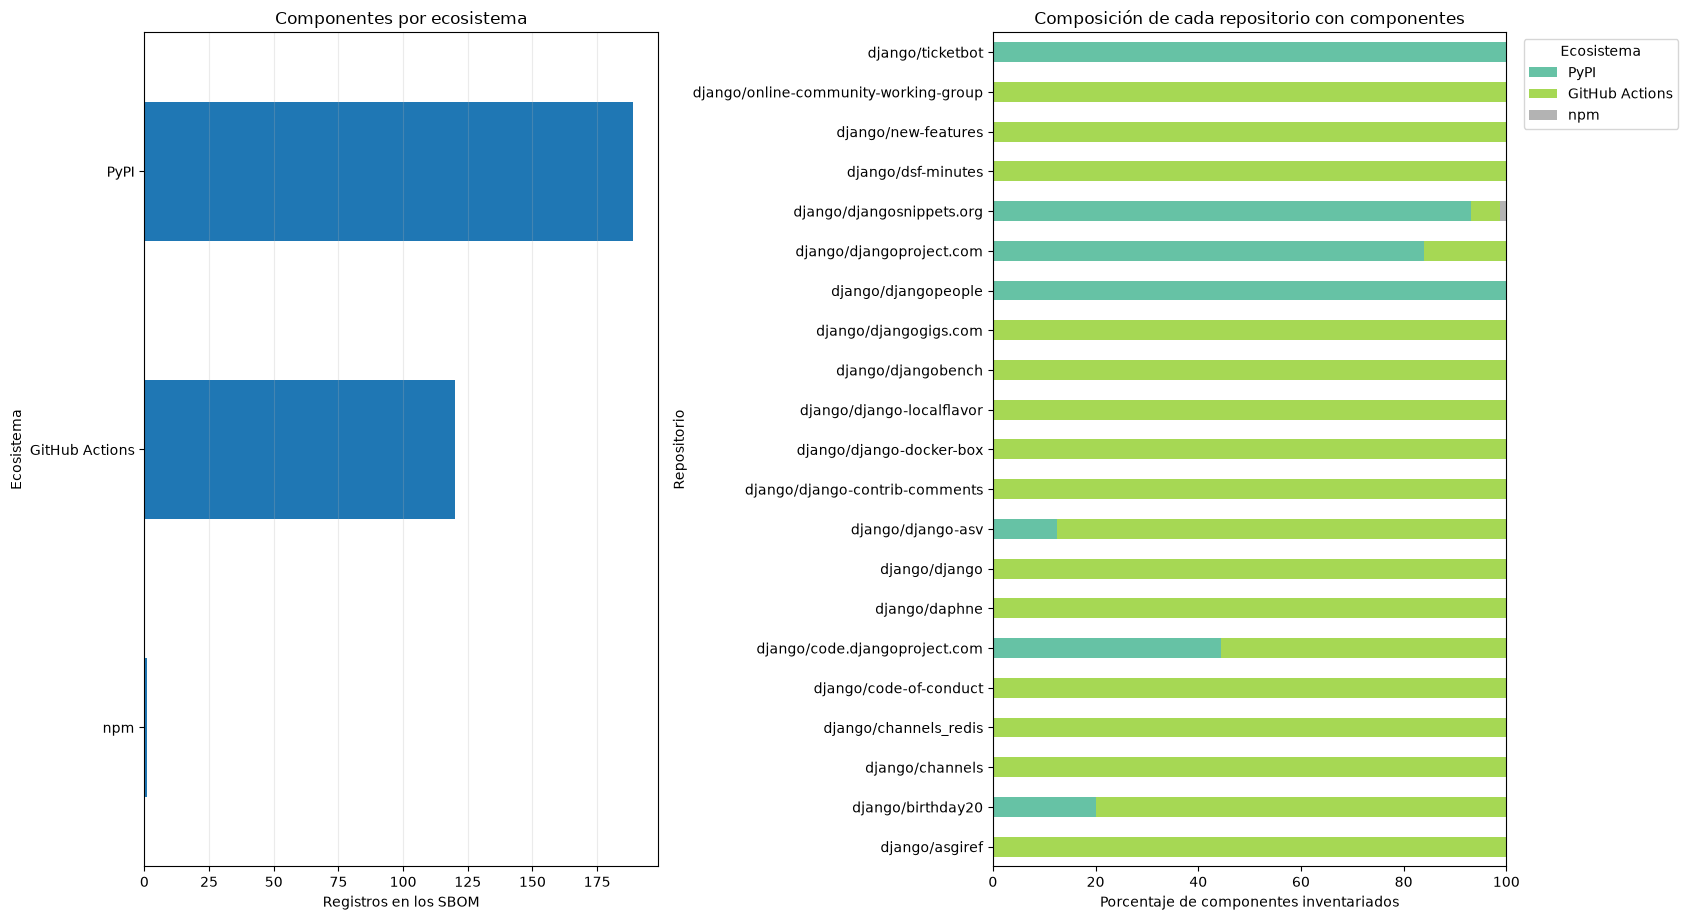

In [26]:
if componentes_sbom.empty:
    print('No hay componentes en los SBOM válidos cargados; consultar la cobertura.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(17, max(6, len(matriz_ecosistemas) * 0.3)))
    resumen_ecosistemas.set_index('ecosistema')['componentes'].sort_values().plot.barh(ax=axes[0])
    axes[0].set_title('Componentes por ecosistema')
    axes[0].set_xlabel('Registros en los SBOM')
    axes[0].set_ylabel('Ecosistema')
    axes[0].grid(axis='x', alpha=0.25)

    repositorios_con_componentes = matriz_ecosistemas.sum(axis=1) > 0
    (proporciones_ecosistemas.loc[repositorios_con_componentes] * 100).plot.barh(
        stacked=True, ax=axes[1], colormap='Set2',
    )
    axes[1].set_title('Composición de cada repositorio con componentes')
    axes[1].set_xlabel('Porcentaje de componentes inventariados')
    axes[1].set_ylabel('Repositorio')
    axes[1].set_xlim(0, 100)
    axes[1].legend(title='Ecosistema', loc='upper left', bbox_to_anchor=(1.02, 1))
    fig.tight_layout()
    plt.show()


### Interpretación


* **Volumen global:** Se analizaron 31 SBOM válidos que suman 310 componentes en total (10 de estos inventarios se encuentran vacíos por la naturaleza de los repositorios).
* **Polarización de ecosistemas:** El portafolio se divide casi por completo entre **PyPI** (61.0% de los registros, concentrados en 7 repositorios) y **GitHub Actions** (38.7%, distribuidos en 19 proyectos), dejando a `npm` con una presencia puramente marginal (0.3%).
* **Distribución por proyecto:** Las dependencias funcionales de Python pertenecen estrictamente al núcleo de desarrollo de Django, mientras que los flujos de integración continua abarcan de forma transversal a la mayor parte del portafolio.

### Limitaciones

La distribución describe lo que Syft inventarió en esta ejecución. Un inventario vacío no demuestra que el proyecto carezca de dependencias; el resultado depende de los archivos presentes y de los catalogadores utilizados.

Se incluyen componentes de desarrollo, pruebas y automatización. GitHub Actions describe un ecosistema de automatización, no un lenguaje de programación; tampoco se deduce el lenguaje principal del repositorio a partir de sus componentes. Los conteos no distinguen dependencias directas de transitivas y pueden incluir varias versiones o apariciones de un mismo paquete.

La presencia de un componente no implica una vulnerabilidad ni demuestra uso durante la ejecución. Los porcentajes por repositorio ponderan todos sus registros por igual y los porcentajes globales dan más peso a los inventarios grandes. Las preguntas sobre componentes vulnerables y paquetes compartidos se estudian por separado.


## Pregunta 8. ¿Qué repositorios tienen más componentes y qué proporción presenta coincidencias con vulnerabilidades conocidas?

### Método

Se cruzan los componentes cargados en la pregunta 7 con los hallazgos de Grype del dataset de la misma ejecución. La clave de correspondencia contiene **repositorio, ecosistema, nombre y versión**. Para PyPI se comparan los nombres en minúsculas y se sustituyen secuencias de guiones, puntos y guiones bajos por un guion. En los demás ecosistemas se conserva el nombre; las versiones se comparan como texto exacto, sin inferir equivalencias entre versiones ni resolver etiquetas a commits.

Se mantiene la unidad de la pregunta 7: registros de componentes del SBOM. Cada registro se marca una sola vez como afectado si su clave tiene al menos una coincidencia de Grype, independientemente del número de identificadores asociados. Si la misma identidad aparece en varios registros del SBOM, cada registro contribuye al inventario y al numerador; por eso también se informa el número de identidades distintas afectadas.

**Proporción afectada = registros de componentes con coincidencias / registros de componentes inventariados.** Los identificadores distintos por componente se conservan como detalle, pero no se suman para calcular esa proporción.

La proporción solo se presenta cuando el SBOM está disponible y es válido, Grype terminó como `analyzed`, todos los componentes tienen una clave utilizable y todos los hallazgos de Grype tienen correspondencia en el inventario. Si alguna condición falla, queda no definida. Un inventario vacío también tiene proporción no definida. Una proporción cero significa ausencia de coincidencias observadas bajo esas condiciones, no ausencia demostrada de vulnerabilidades.


In [27]:
import re


def clave_componente(repository, ecosystem, name, version):
    values = (repository, ecosystem, name, version)
    if any(not isinstance(value, str) or not value.strip() for value in values):
        return None
    if ecosystem == 'Sin clasificar':
        return None
    name = name.strip()
    if ecosystem == 'PyPI':
        name = re.sub(r'[-_.]+', '-', name).lower()
    return (repository, ecosystem, name, version.strip())


def ecosistema_grype(package_type):
    if not isinstance(package_type, str) or not package_type.strip():
        return 'Sin clasificar'
    package_type = package_type.strip().lower()
    return {
        'python': 'PyPI', 'pypi': 'PyPI', 'npm': 'npm',
        'github-action': 'GitHub Actions', 'github-action-workflow': 'GitHub Actions',
    }.get(package_type, f'Syft: {package_type}')


def comparar_componentes_grype(components, sbom_coverage, all_findings, repo_table):
    detail = components.copy()
    detail['clave'] = pd.Series([
        clave_componente(row.repository, row.ecosistema, row.name, row.version)
        for row in detail.itertuples()
    ], index=detail.index, dtype=object)
    grype = all_findings.loc[all_findings['tool'] == 'grype'].copy()
    grype['clave'] = pd.Series([
        clave_componente(row.repository, ecosistema_grype(row.package_type), row.package, row.version)
        for row in grype.itertuples()
    ], index=grype.index, dtype=object)

    known_keys = set(detail['clave'].dropna())
    grype['tiene_correspondencia'] = grype['clave'].map(
        lambda key: key is not None and key in known_keys
    )
    unmatched = grype.loc[~grype['tiene_correspondencia']].copy()
    matched = grype.loc[grype['tiene_correspondencia']]
    ids_by_key = matched.groupby('clave')['vulnerability_id'].agg(
        lambda values: sorted(set(values.dropna()))
    ).to_dict()
    detail['identificadores_grype'] = detail['clave'].map(lambda key: ids_by_key.get(key, []))
    detail['identificadores_distintos'] = detail['identificadores_grype'].map(len)
    detail['con_coincidencias'] = detail['identificadores_distintos'] > 0
    detail['clave_disponible'] = detail['clave'].notna()

    component_metrics = detail.groupby('repository').agg(
        componentes_identificables=('clave_disponible', 'sum'),
        componentes_con_coincidencias=('con_coincidencias', 'sum'),
    )
    affected_identities = (
        detail.loc[detail['con_coincidencias']]
        .groupby('repository')['clave'].nunique().rename('identidades_afectadas')
    )
    summary = (
        sbom_coverage[['repository', 'sbom_status', 'componentes_cargados']]
        .rename(columns={'componentes_cargados': 'componentes_totales'})
        .merge(repo_table[['repository', 'grype_status']], on='repository', validate='one_to_one')
        .merge(component_metrics, on='repository', how='left', validate='one_to_one')
        .merge(affected_identities, on='repository', how='left', validate='one_to_one')
        .merge(grype.groupby('repository').size().rename('hallazgos_grype'),
               on='repository', how='left', validate='one_to_one')
        .merge(unmatched.groupby('repository').size().rename('hallazgos_sin_correspondencia'),
               on='repository', how='left', validate='one_to_one')
    )
    metrics = ['componentes_identificables', 'componentes_con_coincidencias', 'identidades_afectadas']
    valid_inventory = summary['sbom_status'].eq('generated')
    summary[metrics] = summary[metrics].fillna(0)
    summary.loc[~valid_inventory, metrics] = float('nan')
    for column in ['hallazgos_grype', 'hallazgos_sin_correspondencia']:
        summary[column] = summary[column].fillna(0).astype(int)
    summary['componentes_sin_clave'] = summary['componentes_totales'] - summary['componentes_identificables']
    summary['cobertura_identificacion'] = (
        summary['componentes_identificables'] / summary['componentes_totales'].replace(0, float('nan'))
    )
    summary['comparacion_completa'] = (
        valid_inventory & summary['grype_status'].eq('analyzed')
        & summary['componentes_sin_clave'].eq(0)
        & summary['hallazgos_sin_correspondencia'].eq(0)
    )
    summary['proporcion_afectada'] = (
        summary['componentes_con_coincidencias']
        / summary['componentes_totales'].replace(0, float('nan'))
    ).where(summary['comparacion_completa'])
    summary = summary.sort_values(
        ['componentes_totales', 'repository'], ascending=[False, True], na_position='last',
    ).reset_index(drop=True)
    return summary, detail, unmatched


resumen_componentes, detalle_componentes, grype_sin_correspondencia = comparar_componentes_grype(
    componentes_sbom, cobertura_sbom, findings, repositories,
)


In [28]:
if grype_sin_correspondencia.empty:
    print('Todos los registros de Grype tienen correspondencia exacta con el inventario cargado.')
else:
    print(f'Atención: Se detectaron {len(grype_sin_correspondencia)} registros de Grype sin correspondencia directa en el inventario.')

print(f"Cruce completado para {len(resumen_componentes)} repositorios. Análisis de vulnerabilidades listo para graficar.")

Todos los registros de Grype tienen correspondencia exacta con el inventario cargado.
Cruce completado para 31 repositorios. Análisis de vulnerabilidades listo para graficar.


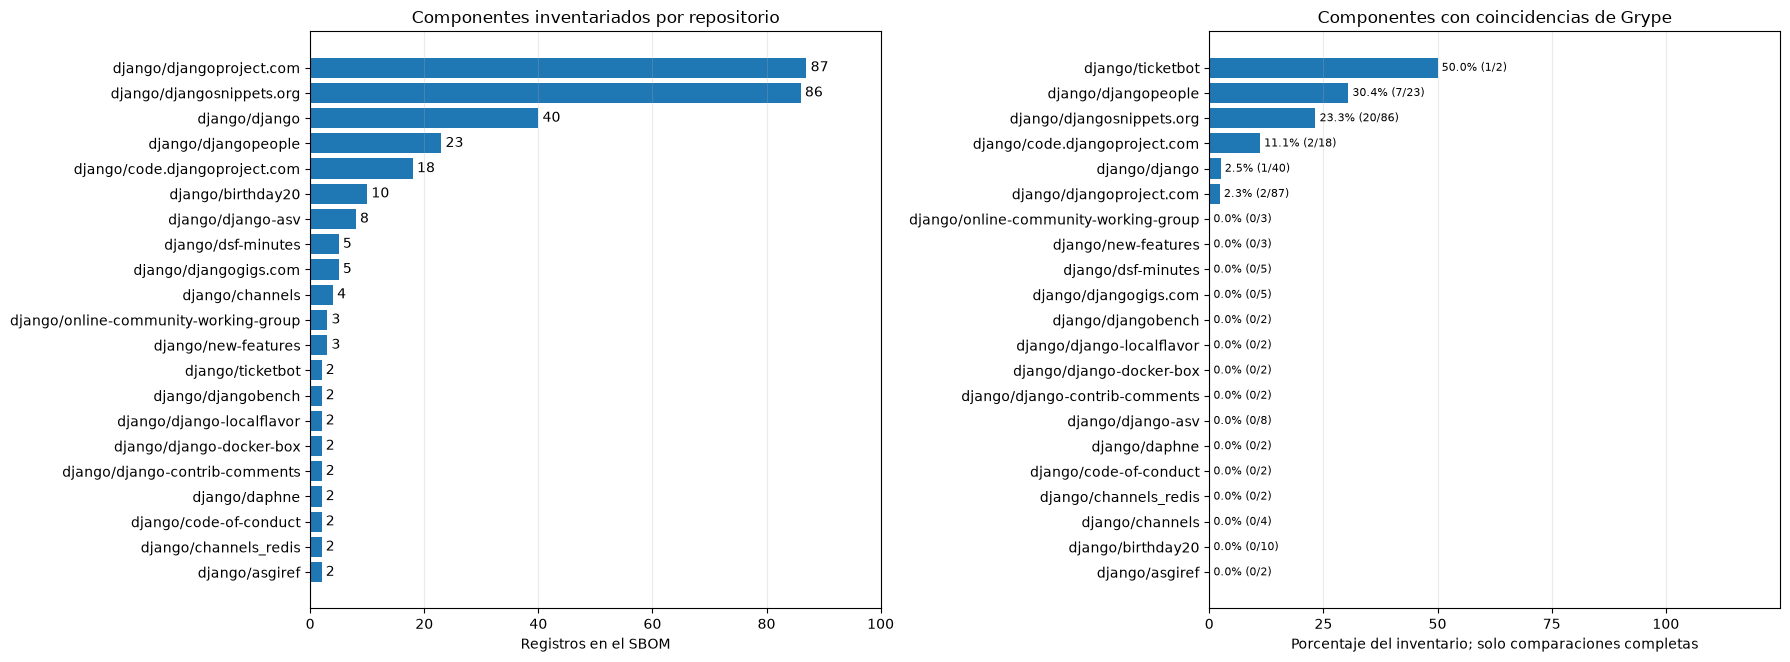

In [29]:
inventarios_grafico = resumen_componentes.loc[
    resumen_componentes['componentes_totales'].gt(0)
].sort_values(['componentes_totales', 'repository'])
proporciones_grafico = resumen_componentes.loc[
    resumen_componentes['proporcion_afectada'].notna()
].sort_values(['proporcion_afectada', 'repository'])

if inventarios_grafico.empty:
    print('No hay inventarios con componentes disponibles para comparar.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(inventarios_grafico) * 0.32)))
    bars = axes[0].barh(inventarios_grafico['repository'], inventarios_grafico['componentes_totales'])
    axes[0].bar_label(bars, fmt='%.0f', padding=3)
    axes[0].set_xlim(0, inventarios_grafico['componentes_totales'].max() * 1.15)
    axes[0].set_title('Componentes inventariados por repositorio')
    axes[0].set_xlabel('Registros en el SBOM')
    axes[0].grid(axis='x', alpha=0.25)
    if proporciones_grafico.empty:
        axes[1].text(0.5, 0.5, 'No hay proporciones con cobertura completa',
                     ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_axis_off()
    else:
        bars = axes[1].barh(proporciones_grafico['repository'], proporciones_grafico['proporcion_afectada'] * 100)
        axes[1].bar_label(bars, labels=[
            f'{row.proporcion_afectada:.1%} ({int(row.componentes_con_coincidencias)}/{int(row.componentes_totales)})'
            for row in proporciones_grafico.itertuples()
        ], padding=3, fontsize=8)
        axes[1].set_xlim(0, 125)
        axes[1].set_xticks([0, 25, 50, 75, 100])
        axes[1].set_title('Componentes con coincidencias de Grype')
        axes[1].set_xlabel('Porcentaje del inventario; solo comparaciones completas')
        axes[1].grid(axis='x', alpha=0.25)
    fig.tight_layout()
    plt.show()


### Interpretación


* **Liderazgo en volumen de inventario:** `django/djangoproject.com` encabeza el portafolio con el mayor número de registros, alcanzando 87 componentes inventariados.
* **Proporción de afectación por vulnerabilidades:** La mayor densidad de coincidencias observada corresponde a `django/ticketbot` con un 50.0% de afectación (1 de 2 componentes), seguido por proyectos de mayor tamaño como `django/djangopeople` (30.4%, 7/23) y `django/djangosnippets.org` (23.3%, 20/86).
* **Ausencia de correlación directa entre volumen y vulnerabilidades:** El análisis demuestra que no existe una dependencia lineal directa entre la cantidad de dependencias inventariadas y la presencia de vulnerabilidades conocidas. Un claro ejemplo es `djangoproject.com`, que a pesar de poseer el mayor volumen de componentes en su inventario, presenta una tasa de afectación marginal (2.3%), lo que refleja una gestión de la cadena de suministro considerablemente más robusta frente a repositorios con menor inventario pero mayor densidad de fallos (como `djangosnippets.org`).
* **Consistencia y cobertura analítica:** Se obtuvieron proporciones calculables para 21 repositorios (mientras que 10 registran inventarios vacíos). El 100% de los registros analizados por Grype cuenta con correspondencia exacta en el inventario de componentes, sin hallazgos huérfanos ni fallos de cobertura.

### Limitaciones

Una coincidencia indica que Grype relaciona un componente con una vulnerabilidad conocida; no confirma que sea explotable en ese repositorio. La proporción no pondera severidad, uso en producción ni alcance durante la ejecución. Un porcentaje elevado sobre pocos componentes debe leerse junto con su numerador y denominador.

La comparación depende de la completitud del SBOM, la cobertura de Grype por ecosistema y la base de vulnerabilidades utilizada. El estado `analyzed` indica que la herramienta terminó, no que cubra todas las vulnerabilidades posibles. Se incluyen dependencias de pruebas, desarrollo y automatización.

La correspondencia por nombre, ecosistema y versión puede asociar varios registros del inventario a una misma identidad. No se infieren equivalencias para versiones textualmente distintas ni se resuelven alias CVE/GHSA; los identificadores asociados se muestran tal como aparecen en la evidencia. Al cambiar de ejecución deben seleccionarse reportes compatibles con la misma revisión del código.


## Pregunta 9. ¿Qué componentes y versiones se comparten entre repositorios, tengan o no hallazgos?

### Método

Se utiliza el inventario completo de la pregunta 7. Se distinguen dos niveles: **paquete compartido**, identificado por ecosistema y nombre normalizado, y **versión compartida**, que añade la versión textual exacta. En ambos casos deben aparecer en al menos dos repositorios distintos. Varias apariciones dentro de un único repositorio no convierten un paquete en compartido.

Se reutiliza la normalización de nombres de PyPI de la pregunta 8. Los registros sin nombre o ecosistema identificable se excluyen de las agrupaciones; los que carecen de versión pueden contribuir a un paquete compartido, pero no a una versión compartida. No se eliminan versiones ni se resuelven tags de GitHub a SHA.

Se muestran repositorios, versiones observadas y registros de inventario. La columna `alguna_coincidencia_grype` solo indica si alguna aparición tiene coincidencias observadas; no filtra el inventario ni convierte su ausencia en garantía de seguridad. La cobertura de SBOM y Grype se conserva en las preguntas 7 y 8.


In [30]:
def resumir_componentes_compartidos(component_detail):
    inventory = component_detail.copy()
    name_keys = [
        clave_componente(row.repository, row.ecosistema, row.name, 'nombre_sin_version')
        for row in inventory.itertuples()
    ]
    inventory['nombre_normalizado'] = [key[2] if key else None for key in name_keys]
    inventory['version_identificada'] = inventory['version'].map(
        lambda value: value.strip() if isinstance(value, str) and value.strip() else None
    )
    usable = inventory.dropna(subset=['nombre_normalizado']).copy()
    group_columns = ['ecosistema', 'nombre_normalizado']
    packages = usable.groupby(group_columns).agg(
        repositorios=('repository', 'nunique'), registros=('repository', 'size'),
        lista_repositorios=('repository', lambda values: sorted(set(values))),
        versiones_observadas=('version_identificada', lambda values: sorted(set(values.dropna()))),
        alguna_coincidencia_grype=('con_coincidencias', 'any'),
    ).reset_index()
    packages = packages.loc[packages['repositorios'] >= 2].sort_values(
        ['repositorios', 'registros', 'ecosistema', 'nombre_normalizado'],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)
    versions = usable.dropna(subset=['version_identificada']).groupby(
        group_columns + ['version_identificada']
    ).agg(
        repositorios=('repository', 'nunique'), registros=('repository', 'size'),
        lista_repositorios=('repository', lambda values: sorted(set(values))),
        alguna_coincidencia_grype=('con_coincidencias', 'any'),
    ).reset_index()
    versions = versions.loc[versions['repositorios'] >= 2].sort_values(
        ['repositorios', 'registros', 'ecosistema', 'nombre_normalizado', 'version_identificada'],
        ascending=[False, False, True, True, True],
    ).reset_index(drop=True)
    shared_detail = usable.merge(
        packages[group_columns], on=group_columns, how='inner', validate='many_to_one',
    )
    exclusions = {
        'sin_identidad_paquete': int(inventory['nombre_normalizado'].isna().sum()),
        'identificables_sin_version': int(usable['version_identificada'].isna().sum()),
    }
    return packages, versions, shared_detail, exclusions


paquetes_sbom_compartidos, versiones_sbom_compartidas, detalle_compartidos_sbom, exclusiones_compartidos = (
    resumir_componentes_compartidos(detalle_componentes)
)

print("Análisis de componentes compartidos completado:")
print(f"- Paquetes compartidos detectados: {len(paquetes_sbom_compartidos)}")
print(f"- Versiones compartidas detectadas: {len(versiones_sbom_compartidas)}")
print(f"- Registros excluidos o sin versión: {exclusiones_compartidos}")

Análisis de componentes compartidos completado:
- Paquetes compartidos detectados: 46
- Versiones compartidas detectadas: 20
- Registros excluidos o sin versión: {'sin_identidad_paquete': 0, 'identificables_sin_version': 0}


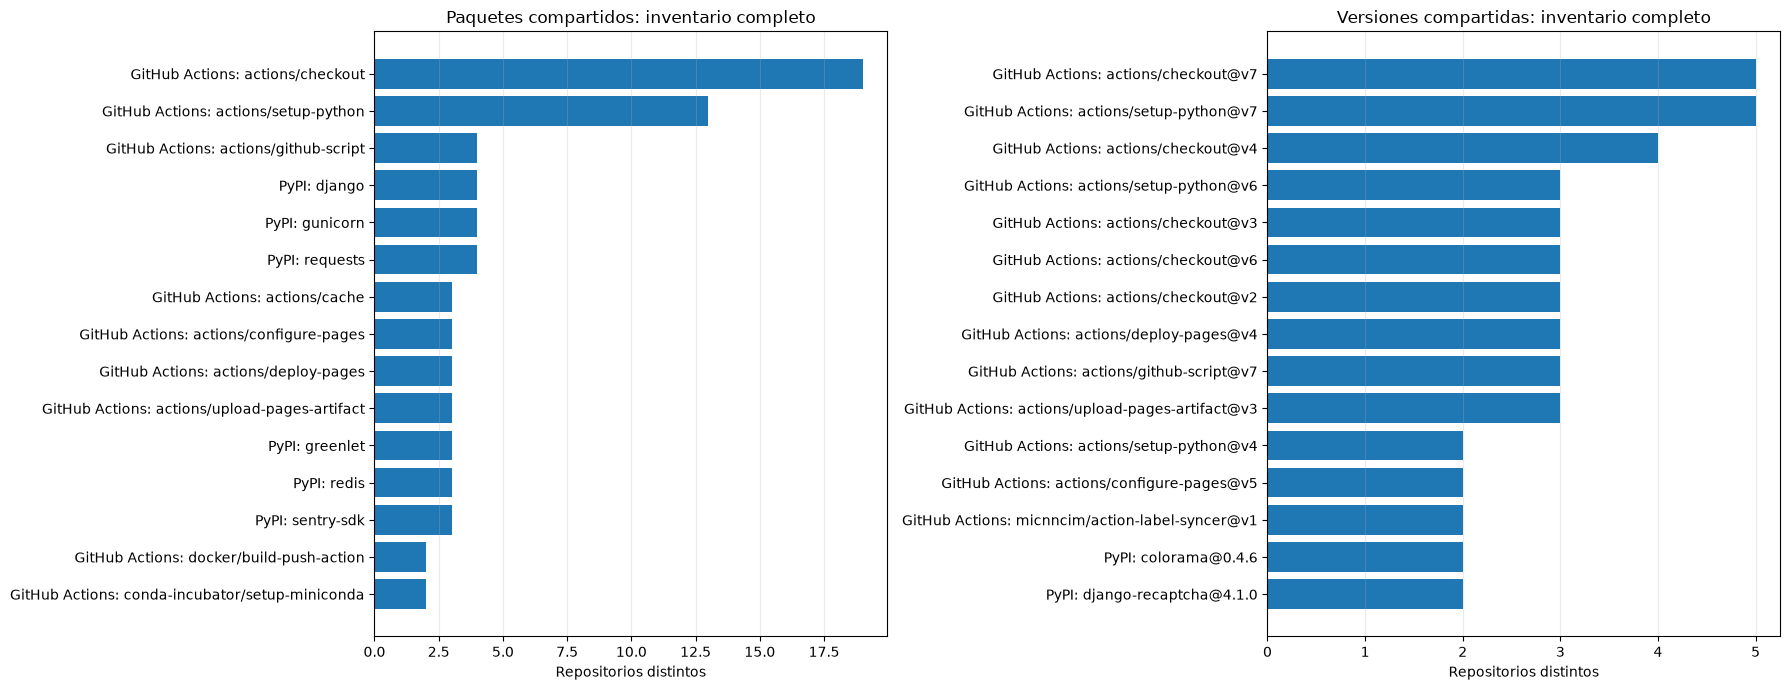

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for axis, frame, title, include_version in [
    (axes[0], paquetes_sbom_compartidos, 'Paquetes compartidos: inventario completo', False),
    (axes[1], versiones_sbom_compartidas, 'Versiones compartidas: inventario completo', True),
]:
    top = frame.head(15).iloc[::-1]
    labels = top['ecosistema'] + ': ' + top['nombre_normalizado']
    if include_version:
        labels = labels + '@' + top['version_identificada']
    axis.barh(labels, top['repositorios'])
    axis.set_title(title)
    axis.set_xlabel('Repositorios distintos')
    axis.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()


### Interpretación


**Dominio de CI/CD**: La gran mayoría de los componentes compartidos corresponde a herramientas de automatización e infraestructura mediante GitHub Actions, destacando actions/checkout (19 repositorios) y actions/setup-python (13 repositorios).   
**Fragmentación de versiones**: A pesar de la alta reutilización de paquetes comunes, se observa una marcada dispersión en las iteraciones empleadas; por ejemplo, actions/checkout se despliega a través de múltiples versiones textuales distintas en el portafolio (como v7, v4, v3, v6 y v2), evidenciando ritmos de actualización descentralizados entre proyectos.    
**Dependencias de backend**: Librerías de Python como django, gunicorn y requests se reutilizan de forma idéntica en 4 repositorios cada una.   
**Perfil de seguridad**: 33 de estos paquetes compartidos no presentan coincidencias con Grype, reflejando una base común estable pero sujeta a monitoreo continuo.

### Limitaciones

La coincidencia de nombre y versión no demuestra que dos repositorios utilicen el mismo artefacto binario, configuración o contexto de ejecución. Tags como `main` o `stable` pueden representar revisiones distintas y no se resuelven en este análisis. Las PURL originales se conservan como detalle, pero la comparación no utiliza sus qualifiers ni subrutas.

La ausencia de coincidencias de Grype no prueba ausencia de vulnerabilidades. Los componentes de desarrollo y automatización también forman parte del inventario. Los SBOM ausentes o incompletos limitan el número de repositorios en los que se puede observar una dependencia compartida.


## Resultados para el Visualizer

La siguiente celda exporta `analysis.json` en `analyzer/outputs/<organización>/<ejecución>/`. El archivo reúne las nueve preguntas con sus respuestas cualitativas, datos cuantitativos, especificaciones de gráficos, métodos, denominadores, limitaciones y estado de la evidencia. Incluye la correlación de Spearman y las métricas de concentración, comparación y repetición calculadas en las secciones anteriores.

Las tablas conservan los valores ausentes como `null`; las proporciones son fracciones entre 0 y 1. Se registran hashes de las entradas y del código utilizado para enlazar cada exportación con la evidencia.

El Visualizer debe consumir este archivo y respetar sus estados y denominadores. La evidencia original permanece en `analyzer/data` y en los resultados del Miner. El formato se documenta en `analyzer/docs/visualizer-contract.md`.


In [32]:
import sys

if str(ANALYZER_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYZER_ROOT))
from visualizer_export import export_analysis

VISUALIZER_PATH = (
    ANALYZER_ROOT / 'outputs' / dataset['organization'] / dataset['clone_run'] / 'analysis.json'
)
export_analysis(globals(), ANALYZER_ROOT / 'notebooks/analyzer.ipynb', VISUALIZER_PATH)
print(f'Salida para el Visualizer: {VISUALIZER_PATH.relative_to(REPOSITORY_ROOT).as_posix()}')


Salida para el Visualizer: analyzer/outputs/django/clone-x269596i/analysis.json
